Import libraries:

In [ ]:
!pip install rapidfuzz ydata-profiling sweetviz lux autoviz plotly -U xgboost recordlinkage lightgbm

In [ ]:
import json
import ast
import re
import lux
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as mno
import holidays
import recordlinkage

import networkx as nx
import ydata_profiling as yp
import sweetviz as sv
from autoviz import AutoViz_Class
import plotly.express as px
from rapidfuzz import fuzz
from geopy.geocoders import Nominatim
import statsmodels.api as sm
from scipy.stats import chi2_contingency, chisquare, ks_2samp

from sklearn.experimental import enable_iterative_imputer, enable_halving_search_cv
from sklearn.impute import IterativeImputer, KNNImputer, SimpleImputer
from sklearn.linear_model import BayesianRidge, LogisticRegression
from sklearn.ensemble import IsolationForest, RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors, KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, HalvingGridSearchCV
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, accuracy_score

import lightgbm as lgb
from xgboost import XGBClassifier
from xgboost import plot_importance

%matplotlib inline

Imported v0.1.905. Please call AutoViz in this sequence:
    AV = AutoViz_Class()
    %matplotlib inline
    dfte = AV.AutoViz(filename, sep=',', depVar='', dfte=None, header=0, verbose=1, lowess=False,
               chart_format='svg',max_rows_analyzed=150000,max_cols_analyzed=30, save_plot_dir=None)


In [ ]:
crime = pd.read_csv("/content/CRIMES/crime.csv", encoding="ISO-8859-1")
offense_codes = pd.read_csv("/content/CRIMES/offense_codes.csv", encoding="ISO-8859-1")

In [ ]:
with open("/content/CRIMES/crime.csv", 'r', encoding="ISO-8859-1") as f:
    for i in range(10):
        print(f.readline())

INCIDENT_NUMBER,OFFENSE_CODE,OFFENSE_CODE_GROUP,OFFENSE_DESCRIPTION,DISTRICT,REPORTING_AREA,SHOOTING,OCCURRED_ON_DATE,YEAR,MONTH,DAY_OF_WEEK,HOUR,UCR_PART,STREET,Lat,Long,Location

I182070945,00619,Larceny,LARCENY ALL OTHERS,D14,808,,2018-09-02 13:00:00,2018,9,Sunday,13,Part One,LINCOLN ST,42.35779134,-71.13937053,"(42.35779134, -71.13937053)"

I182070943,01402,Vandalism,VANDALISM,C11,347,,2018-08-21 00:00:00,2018,8,Tuesday,0,Part Two,HECLA ST,42.30682138,-71.06030035,"(42.30682138, -71.06030035)"

I182070941,03410,Towed,TOWED MOTOR VEHICLE,D4,151,,2018-09-03 19:27:00,2018,9,Monday,19,Part Three,CAZENOVE ST,42.34658879,-71.07242943,"(42.34658879, -71.07242943)"

I182070940,03114,Investigate Property,INVESTIGATE PROPERTY,D4,272,,2018-09-03 21:16:00,2018,9,Monday,21,Part Three,NEWCOMB ST,42.33418175,-71.07866441,"(42.33418175, -71.07866441)"

I182070938,03114,Investigate Property,INVESTIGATE PROPERTY,B3,421,,2018-09-03 21:05:00,2018,9,Monday,21,Part Three,DELHI ST,42.27536542,-71.0903610

# **1. DATA PROFILING AND DATA QUALITY ASSESSMENT**



## 1.1. General information on data

In [ ]:
print("=== CRIME DATA — BASIC INFO ===")
print("Shape:", crime.shape)
print("Columns:", list(crime.columns))
print("\nData types:\n", crime.dtypes)
print("\nFirst 5 rows:\n", crime.head(), "\n")

=== CRIME DATA — BASIC INFO ===
Shape: (319073, 17)
Columns: ['INCIDENT_NUMBER', 'OFFENSE_CODE', 'OFFENSE_CODE_GROUP', 'OFFENSE_DESCRIPTION', 'DISTRICT', 'REPORTING_AREA', 'SHOOTING', 'OCCURRED_ON_DATE', 'YEAR', 'MONTH', 'DAY_OF_WEEK', 'HOUR', 'UCR_PART', 'STREET', 'Lat', 'Long', 'Location']

Data types:
 INCIDENT_NUMBER         object
OFFENSE_CODE             int64
OFFENSE_CODE_GROUP      object
OFFENSE_DESCRIPTION     object
DISTRICT                object
REPORTING_AREA          object
SHOOTING                object
OCCURRED_ON_DATE        object
YEAR                     int64
MONTH                    int64
DAY_OF_WEEK             object
HOUR                     int64
UCR_PART                object
STREET                  object
Lat                    float64
Long                   float64
Location                object
dtype: object

First 5 rows:
   INCIDENT_NUMBER  OFFENSE_CODE   OFFENSE_CODE_GROUP   OFFENSE_DESCRIPTION   \
0    I182070945         619                   Larceny    

In [ ]:
print("=== MISSING VALUES PER COLUMN ===")
missing_summary = crime.isna().sum().sort_values(ascending=False)
print(missing_summary, "\n")

=== MISSING VALUES PER COLUMN ===
SHOOTING               318054
Lat                     19999
Long                    19999
STREET                  10871
DISTRICT                 1765
UCR_PART                   90
INCIDENT_NUMBER             0
OFFENSE_CODE_GROUP          0
OFFENSE_CODE                0
YEAR                        0
OCCURRED_ON_DATE            0
REPORTING_AREA              0
OFFENSE_DESCRIPTION         0
HOUR                        0
DAY_OF_WEEK                 0
MONTH                       0
Location                    0
dtype: int64 



In [ ]:
print("=== NUMBER OF UNIQUE VALUES PER COLUMN ===")
unique_counts = crime.nunique().sort_values(ascending=False)
print(unique_counts, "\n")

=== NUMBER OF UNIQUE VALUES PER COLUMN ===
INCIDENT_NUMBER        282517
OCCURRED_ON_DATE       233229
Location                18194
Lat                     18178
Long                    18178
STREET                   4657
REPORTING_AREA            879
OFFENSE_DESCRIPTION       244
OFFENSE_CODE              222
OFFENSE_CODE_GROUP         67
HOUR                       24
DISTRICT                   12
MONTH                      12
DAY_OF_WEEK                 7
YEAR                        4
UCR_PART                    4
SHOOTING                    1
dtype: int64 



In [ ]:
print("=== EXAMPLES OF UNIQUE VALUES ===")
for col in crime.columns:
    unique_vals = crime[col].unique()
    if len(unique_vals) < 10:
        print(f"{col}: {unique_vals}")
    else:
        print(f"{col}: {len(unique_vals)} unique values (showing first 5) → {unique_vals[:5]}")
print()

=== EXAMPLES OF UNIQUE VALUES ===
INCIDENT_NUMBER: 282517 unique values (showing first 5) → ['I182070945' 'I182070943' 'I182070941' 'I182070940' 'I182070938']
OFFENSE_CODE: 222 unique values (showing first 5) → [ 619 1402 3410 3114 3820]
OFFENSE_CODE_GROUP: 67 unique values (showing first 5) → ['Larceny' 'Vandalism' 'Towed' 'Investigate Property'
 'Motor Vehicle Accident Response']
OFFENSE_DESCRIPTION: 244 unique values (showing first 5) → ['LARCENY ALL OTHERS' 'VANDALISM' 'TOWED MOTOR VEHICLE'
 'INVESTIGATE PROPERTY' 'M/V ACCIDENT INVOLVING PEDESTRIAN - INJURY']
DISTRICT: 13 unique values (showing first 5) → ['D14' 'C11' 'D4' 'B3' 'B2']
REPORTING_AREA: 879 unique values (showing first 5) → ['808' '347' '151' '272' '421']
SHOOTING: [nan 'Y']
OCCURRED_ON_DATE: 233229 unique values (showing first 5) → ['2018-09-02 13:00:00' '2018-08-21 00:00:00' '2018-09-03 19:27:00'
 '2018-09-03 21:16:00' '2018-09-03 21:05:00']
YEAR: [2018 2017 2016 2015]
MONTH: 12 unique values (showing first 5) → [ 9 

In [ ]:
print("=== DESCRIPTIVE STATISTICS — NUMERIC COLUMNS ===")
print(crime.describe().transpose(), "\n")

print("=== DESCRIPTIVE STATISTICS — CATEGORICAL COLUMNS ===")
print(crime.describe(include=['object']).transpose(), "\n")

=== DESCRIPTIVE STATISTICS — NUMERIC COLUMNS ===
                count      mean          std          min          25%      \
OFFENSE_CODE  319073.0  2317.546956  1185.285543   111.000000  1001.000000   
YEAR          319073.0  2016.560586     0.996344  2015.000000  2016.000000   
MONTH         319073.0     6.609719     3.273691     1.000000     4.000000   
HOUR          319073.0    13.118205     6.294205     0.000000     9.000000   
Lat           299074.0    42.214381     2.159766    -1.000000    42.297442   
Long          299074.0   -70.908272     3.493618   -71.178674   -71.097135   

                  50%          75%          max      
OFFENSE_CODE  2907.000000  3201.000000  3831.000000  
YEAR          2017.000000  2017.000000  2018.000000  
MONTH            7.000000     9.000000    12.000000  
HOUR            14.000000    18.000000    23.000000  
Lat             42.325538    42.348624    42.395042  
Long           -71.077524   -71.062467    -1.000000   

=== DESCRIPTIVE STATISTI

In [ ]:
print("=== VALUE COUNTS FOR CATEGORICAL COLUMNS ===")
cat_cols = crime.select_dtypes(include=['object']).columns
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(len(crime[col].unique()))
    print(crime[col].value_counts().head(10))
print()

=== VALUE COUNTS FOR CATEGORICAL COLUMNS ===

--- INCIDENT_NUMBER ---
282517
INCIDENT_NUMBER
I162030584    13
I152080623    11
I182065208    10
I172013170    10
I172096394    10
I172056883     9
I162098170     9
I172054429     9
I172022524     9
I162071327     9
Name: count, dtype: int64

--- OFFENSE_CODE_GROUP ---
67
OFFENSE_CODE_GROUP
Motor Vehicle Accident Response    37132
Larceny                            25935
Medical Assistance                 23540
Investigate Person                 18750
Other                              18075
Drug Violation                     16548
Simple Assault                     15826
Vandalism                          15415
Verbal Disputes                    13099
Towed                              11287
Name: count, dtype: int64

--- OFFENSE_DESCRIPTION ---
244
OFFENSE_DESCRIPTION
SICK/INJURED/MEDICAL - PERSON            18783
INVESTIGATE PERSON                       18754
M/V - LEAVING SCENE - PROPERTY DAMAGE    16323
VANDALISM                      

In [ ]:
print("=== OFFENSE_CODES FILE EXPLORATION ===")
print("Shape:", offense_codes.shape)
print("Columns:", list(offense_codes.columns))
print("\nFirst 5 rows:\n", offense_codes.head())
print("\nUnique CODE values:", offense_codes['CODE'].nunique())

=== OFFENSE_CODES FILE EXPLORATION ===
Shape: (576, 2)
Columns: ['CODE', 'NAME']

First 5 rows:
    CODE                   NAME                  
0   612         LARCENY PURSE SNATCH - NO FORCE 
1   613                      LARCENY SHOPLIFTING
2   615  LARCENY THEFT OF MV PARTS & ACCESSORIES
3  1731                                   INCEST
4  3111                LICENSE PREMISE VIOLATION

Unique CODE values: 425


In [ ]:
# Group by OFFENSE_CODE and count unique NAME values
name_counts = offense_codes.groupby('CODE')['NAME'].nunique()

# Check if any code has more than one unique NAME
codes_multiple_names = name_counts[name_counts > 1]

if codes_multiple_names.empty:
    print("All OFFENSE_CODE have a single NAME.")
else:
    size = codes_multiple_names.sum()
    print(f"The following {size} OFFENSE_CODE have more than one NAME:")
    print(codes_multiple_names)

The following 136 OFFENSE_CODE have more than one NAME:
CODE
111     2
301     2
311     2
351     2
361     2
413     2
423     2
520     2
521     2
522     2
540     2
541     2
542     2
611     2
612     2
613     2
614     2
615     2
616     2
617     2
618     2
619     2
706     2
727     2
735     2
801     2
802     2
1001    2
1102    2
1107    2
1415    2
1501    2
1502    2
1503    2
1603    2
1605    2
1702    2
1703    2
1842    2
1843    2
1847    2
1848    2
1870    2
2003    2
2004    2
2006    2
2101    2
2102    2
2204    2
2405    2
2407    2
2606    2
2622    2
2636    2
2642    2
2670    2
2906    2
2907    2
3008    2
3016    2
3029    2
3108    2
3116    2
3160    2
3203    2
3303    2
3305    2
3403    2
Name: NAME, dtype: int64


In [ ]:
for code in codes_multiple_names.index:
    names = offense_codes[offense_codes['CODE'] == code]['NAME'].unique()
    print(f"CODE {code} has multiple NAMEs: {names}")

CODE 111 has multiple NAMEs: ['MURDER, NON-NEGLIGIENT MANSLAUGHTER'
 'MURDER NON-NEGLIGIENT MANSLAUGHTER']
CODE 301 has multiple NAMEs: ['ROBBERY - STREET' 'ROBBERY - FIREARM - BANK']
CODE 311 has multiple NAMEs: ['ROBBERY - COMMERCIAL' 'ROBBERY - KNIFE - CHAIN STORE']
CODE 351 has multiple NAMEs: ['ROBBERY - BANK' 'ROBBERY ATTEMPT - KNIFE - CHAIN STORE']
CODE 361 has multiple NAMEs: ['ROBBERY - OTHER' 'ROBBERY ATTEMPT - OTHER WEAPON - MISCELLANEOUS']
CODE 413 has multiple NAMEs: ['ASSAULT - AGGRAVATED - BATTERY' 'ASSAULT D/W - OTHER']
CODE 423 has multiple NAMEs: ['ASSAULT - AGGRAVATED' 'ASSAULT & BATTERY D/W - OTHER ON POLICE OFFICER']
CODE 520 has multiple NAMEs: ['BURGLARY - RESIDENTIAL - FORCE' 'B&E RESIDENCE DAY - FORCE']
CODE 521 has multiple NAMEs: ['BURGLARY - RESIDENTIAL - ATTEMPT' 'B&E RESIDENCE DAY - ATTEMPT FORCE']
CODE 522 has multiple NAMEs: ['BURGLARY - RESIDENTIAL - NO FORCE' 'B&E RESIDENCE DAY - NO FORCE']
CODE 540 has multiple NAMEs: ['BURGLARY - COMMERICAL - FORCE' 

In [ ]:
# Group by NAME and count unique CODE values
name_code_counts = offense_codes.groupby('NAME')['CODE'].nunique()

# Filter names that have more than 1 unique CODE
duplicate_names = name_code_counts[name_code_counts > 1]

print("\n=== NAMES ASSOCIATED WITH MULTIPLE CODES ===")
print(duplicate_names)


=== NAMES ASSOCIATED WITH MULTIPLE CODES ===
NAME
B&E NON-RESIDENCE DAY - NO PROP TAKEN             2
DEATH INVESTIGATION                               2
DRUGS - POSS CLASS B - INTENT TO MFR DIST DISP    2
DRUGS - POSS CLASS C - INTENT TO MFR DIST DISP    2
DRUGS - SICK ASSIST - HEROIN                      2
FIRE REPORT/ALARM - FALSE                         2
INVESTIGATION FOR ANOTHER AGENCY                  2
M/V - LEAVING SCENE - PERSONAL INJURY             2
M/V - LEAVING SCENE - PROPERTY DAMAGE             2
M/V ACCIDENT - OTHER                              2
M/V ACCIDENT - PERSONAL INJURY                    2
M/V ACCIDENT - POLICE VEHICLE                     2
VAL - OPERATING AFTER REV/SUSP.                   2
VAL - OPERATING W/O AUTHORIZATION LAWFUL          2
Name: CODE, dtype: int64


In [ ]:
# Merge check between datasets
merged = crime.merge(offense_codes, how='left', left_on='OFFENSE_CODE', right_on='CODE')
missing_codes = merged['NAME'].isna().sum()
print(f"\nNumber of crime records with missing offense description after merge: {missing_codes}")
print(f"Total records after merge: {merged.shape[0]}\n")


Number of crime records with missing offense description after merge: 0
Total records after merge: 577880



In [ ]:
print("=== BASIC DATA CONSISTENCY CHECKS ===")
if 'YEAR' in crime.columns:
    print(f"Years covered: {crime['YEAR'].min()} - {crime['YEAR'].max()}")
if 'MONTH' in crime.columns:
    print(f"Months (unique): {sorted(crime['MONTH'].dropna().unique())}")
if 'DAY_OF_WEEK' in crime.columns:
    print("Days of week:", crime['DAY_OF_WEEK'].unique())
if 'DISTRICT' in crime.columns:
    print("Districts:", crime['DISTRICT'].dropna().unique(), "\n")

=== BASIC DATA CONSISTENCY CHECKS ===
Years covered: 2015 - 2018
Months (unique): [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
Days of week: ['Sunday' 'Tuesday' 'Monday' 'Saturday' 'Friday' 'Wednesday' 'Thursday']
Districts: ['D14' 'C11' 'D4' 'B3' 'B2' 'C6' 'A1' 'E5' 'A7' 'E13' 'E18' 'A15'] 



In [ ]:
# Check if Latitude and Longitude are consistent for each Street
# Group by Street and check the number of unique Latitude and Longitude values in each group
street_coords_consistency = crime.groupby('STREET').agg(
    unique_lat=('Lat', 'nunique'),
    unique_long=('Long', 'nunique')
)

# Filter for streets where there is more than one unique Latitude or Longitude
inconsistent_streets = street_coords_consistency[(street_coords_consistency['unique_lat'] > 1) | (street_coords_consistency['unique_long'] > 1)]

print("Streets with inconsistent Latitude or Longitude values:")
print(inconsistent_streets)

if len(inconsistent_streets) == 0:
    print("\nAll streets have consistent Latitude and Longitude values.")
else:
    print(f"\nFound {len(inconsistent_streets)} streets with inconsistent coordinates.")

Streets with inconsistent Latitude or Longitude values:
                 unique_lat  unique_long
STREET                                  
A ST                 30          30     
ABBOT ST              3           3     
ABBOTSFORD ST         4           4     
ACADEMY HILL RD      10          10     
ACADEMY RD            3           3     
...                     ...          ...
WYVERN ST             3           3     
YARMOUTH ST           3           3     
YAWKEY WAY            2           2     
ZAMORA ST             2           2     
ZEIGLER ST            6           6     

[2411 rows x 2 columns]

Found 2411 streets with inconsistent coordinates.


Duplication

In [ ]:
if crime.duplicated().sum() > 0:
    print(f"Duplicate rows found: {crime.duplicated().sum()}")
else:
    print("No exact duplicates found.")

Duplicate rows found: 23


Detect potential data issues

In [ ]:
# Check for impossible coordinates
if ('Lat' in crime.columns) and ('Long' in crime.columns):
    invalid_lat = crime[(crime['Lat'] > 90) | (crime['Lat'] < -90)]
    invalid_long = crime[(crime['Long'] > 180) | (crime['Long'] < -180)]
    print(f"Invalid latitude values: {len(invalid_lat)}")
    print(f"Invalid longitude values: {len(invalid_long)}")

Invalid latitude values: 0
Invalid longitude values: 0


In [ ]:
# Get max and min values for Latitude and Longitude
min_latitude = crime['Lat'].min()
max_latitude = crime['Lat'].max()
min_longitude = crime['Long'].min()
max_longitude = crime['Long'].max()

print(f"Minimum Latitude: {min_latitude}")
print(f"Maximum Latitude: {max_latitude}")
print(f"Minimum Longitude: {min_longitude}")
print(f"Maximum Longitude: {max_longitude}")

Minimum Latitude: -1.0
Maximum Latitude: 42.39504158
Minimum Longitude: -71.17867378
Maximum Longitude: -1.0


In [ ]:
# Check for missing or empty offense codes
if 'OFFENSE_CODE' in crime.columns:
    empty_offenses = crime[crime['OFFENSE_CODE'].isna()]
    print(f"Missing OFFENSE_CODE entries: {len(empty_offenses)}\n")

if 'OFFENSE_CODE' in crime.columns and 'CODE' in offense_codes.columns:
    unique_codes_crime = set(crime['OFFENSE_CODE'].unique())
    unique_codes_ref = set(offense_codes['CODE'].unique())
    missing_in_ref = unique_codes_crime - unique_codes_ref
    print(f"Offense codes in crime.csv but not in offense_codes.csv: {len(missing_in_ref)}\n")

Missing OFFENSE_CODE entries: 0

Offense codes in crime.csv but not in offense_codes.csv: 0



In [ ]:
# Check for "NaN" string values
PSEUDO_NANS = {
    "nan", "none", "null", "n/a", "na", ""
}

def find_string_nans(df):
    report = {}

    string_cols = df.select_dtypes(include=["object", "string"]).columns

    for col in string_cols:
        s = (
            df[col]
            .astype("string")
            .str.strip()
            .str.lower()
        )

        mask = s.isin(PSEUDO_NANS)
        count = mask.sum()

        if count > 0:
            report[col] = {
                "count": int(count),
                "examples": df.loc[mask, col].value_counts().head(5).to_dict()
            }

    if report:
        return pd.DataFrame(report).T.sort_values("count", ascending=False)

    return "No string NaN values."

In [ ]:
pseudo_nan_report = find_string_nans(crime)
pseudo_nan_report

,count,examples
REPORTING_AREA,20250,{' ': 20250}


In [ ]:
print("=== SUMMARY INSIGHTS ===")
print(f"- The dataset contains {crime.shape[0]} rows and {crime.shape[1]} columns.")
print(f"- There are {crime.duplicated().sum()} duplicate rows in the crime dataset.")
missing_cols = crime.columns[crime.isnull().any()].tolist()
print(f"- Columns with missing values: {missing_cols if missing_cols else 'None'}")
if 'DISTRICT' in crime.columns:
    print(f"- There are {crime['DISTRICT'].nunique()} unique districts.")
if 'OFFENSE_CODE_GROUP' in crime.columns:
    print(f"- Top 3 most frequent offense groups:\n{crime['OFFENSE_CODE_GROUP'].value_counts().head(3)}")
if 'YEAR' in crime.columns:
    print(f"- Year range: {crime['YEAR'].min()}–{crime['YEAR'].max()}")
if 'HOUR' in crime.columns:
    print(f"- Most common hour of crime occurrence: {crime['HOUR'].mode().iloc[0]}")

=== SUMMARY INSIGHTS ===
- The dataset contains 319073 rows and 17 columns.
- There are 23 duplicate rows in the crime dataset.
- Columns with missing values: ['DISTRICT', 'SHOOTING', 'UCR_PART', 'STREET', 'Lat', 'Long']
- There are 12 unique districts.
- Top 3 most frequent offense groups:
OFFENSE_CODE_GROUP
Motor Vehicle Accident Response    37132
Larceny                            25935
Medical Assistance                 23540
Name: count, dtype: int64
- Year range: 2015–2018
- Most common hour of crime occurrence: 17


## 1.2. Data Quality Assessment

### Completeness

*Definition*:
Degree to which all required data is present (i.e., no missing values).

*Evaluation formula*:Completeness = Number of non-null values \ Total number of values
	​


In [ ]:
# Count not null values per column
not_null_count = crime.count()
print("Not null values per column:\n", not_null_count, "\n")

# Total not null values
NOT_NULL = not_null_count.sum()
print("Total not null values:", NOT_NULL)

# Count null values per column
null_count = crime.isnull().sum()
print("Null values per column:\n", null_count, "\n")

# Total null values
NULL = null_count.sum()
print("Total null values:", NULL)

# Total cells
TOT = crime.shape[0] * crime.shape[1]
print("Total cells in dataset:", TOT)

# Completeness evaluation
completeness = NOT_NULL / TOT
print("=== COMPLETENESS ===")
print(f"Completeness of dataset: {completeness:.3f}")

Not null values per column:
 INCIDENT_NUMBER        319073
OFFENSE_CODE           319073
OFFENSE_CODE_GROUP     319073
OFFENSE_DESCRIPTION    319073
DISTRICT               317308
REPORTING_AREA         319073
SHOOTING                 1019
OCCURRED_ON_DATE       319073
YEAR                   319073
MONTH                  319073
DAY_OF_WEEK            319073
HOUR                   319073
UCR_PART               318983
STREET                 308202
Lat                    299074
Long                   299074
Location               319073
dtype: int64 

Total not null values: 5053463
Null values per column:
 INCIDENT_NUMBER             0
OFFENSE_CODE                0
OFFENSE_CODE_GROUP          0
OFFENSE_DESCRIPTION         0
DISTRICT                 1765
REPORTING_AREA              0
SHOOTING               318054
OCCURRED_ON_DATE            0
YEAR                        0
MONTH                       0
DAY_OF_WEEK                 0
HOUR                        0
UCR_PART                   90


Missing SHOOTING values are treated as "N".

In [ ]:
# Create a working copy to keep original dataset unchanged
crime_dq = crime.copy()

crime_dq['SHOOTING'] = crime_dq['SHOOTING'].fillna('N')

total_cells = crime_dq.size
non_missing_cells = crime_dq.count().sum()
completeness = non_missing_cells / total_cells

print("=== COMPLETENESS ===")
print(f"Completeness (SHOOTING treated as 'N'): {completeness:.3f}")

=== COMPLETENESS ===
Completeness (SHOOTING treated as 'N'): 0.990


### ACCURACY
*Description*: Degree to which values adhere to real-world rules inferred from data.

Includes numeric ranges, valid categories, reference table checks, and string similarity.



In [ ]:
valid_days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
valid_ucr_parts = ['Part One', 'Part Two', 'Part Three', 'Other']

# Reference check: OFFENSE_CODE must exist in offense_codes
accuracy_offense_code = crime['OFFENSE_CODE'].isin(offense_codes['CODE']).mean()

# Range checks
accuracy_year = crime['YEAR'].between(2000, 2025).mean()
accuracy_month = crime['MONTH'].between(1, 12).mean()
accuracy_hour = crime['HOUR'].between(0, 23).mean()

# Categorical checks
accuracy_day = crime['DAY_OF_WEEK'].isin(valid_days).mean()
accuracy_ucr = crime['UCR_PART'].isin(valid_ucr_parts).mean()

# ----- String similarity checks -----
def similarity(a, b):
    return SequenceMatcher(None, str(a).lower(), str(b).lower()).ratio()

print("\n=== ACCURACY ===")
print(f"OFFENSE_CODE in reference table: {accuracy_offense_code:.3f}")
print(f"YEAR in range: {accuracy_year:.3f}")
print(f"MONTH in 1–12: {accuracy_month:.3f}")
print(f"HOUR in 0–23: {accuracy_hour:.3f}")
print(f"DAY_OF_WEEK valid: {accuracy_day:.3f}")
print(f"UCR_PART valid: {accuracy_ucr:.3f}")


=== ACCURACY ===
OFFENSE_CODE in reference table: 1.000
YEAR in range: 1.000
MONTH in 1–12: 1.000
HOUR in 0–23: 1.000
DAY_OF_WEEK valid: 1.000
UCR_PART valid: 1.000


*Fuzzy string matching*: comparing two strings and computing a score from 0 to 100 based on how closely their characters match.

In [ ]:
acc_copy = crime.copy()

# merge offense_codes to get the NAME corresponding to OFFENSE_CODE
acc_copy = acc_copy.merge(offense_codes[['CODE', 'NAME']],
                          left_on='OFFENSE_CODE',
                          right_on='CODE',
                          how='left', suffixes=('', '_ref'))

# calculate similarity row-wise between DESCRIPTION/GROUP and NAME
acc_copy['desc_sim'] = acc_copy.apply(
    lambda row: fuzz.ratio(str(row['OFFENSE_DESCRIPTION']).lower().strip(),
                           str(row['NAME']).lower().strip()) / 100, axis=1
)
acc_copy['group_sim'] = acc_copy.apply(
    lambda row: fuzz.ratio(str(row['OFFENSE_CODE_GROUP']).lower().strip(),
                           str(row['NAME']).lower().strip()) / 100, axis=1
)

threshold_desc = 0.8
threshold_group = 0.5
accuracy_desc = (acc_copy['desc_sim'] >= threshold_desc).mean()
accuracy_group = (acc_copy['group_sim'] >= threshold_group).mean()

print("\n=== ACCURACY ===")
print(f"OFFENSE_DESCRIPTION similarity ≥ {threshold_desc}: {accuracy_desc:.3f}")
print(f"OFFENSE_CODE_GROUP similarity ≥ {threshold_group}: {accuracy_group:.3f}")


=== ACCURACY ===
OFFENSE_DESCRIPTION similarity ≥ 0.8: 0.854
OFFENSE_CODE_GROUP similarity ≥ 0.5: 0.470


*Token-based Jaccard Similarity*: Measures the fraction of common words between the strings, ignoring order and case.

In [ ]:
def word_similarity(a, b):
    set_a = set(str(a).lower().split())
    set_b = set(str(b).lower().split())
    if not set_a or not set_b:
        return 0
    return len(set_a & set_b) / len(set_a | set_b)  # Jaccard similarity

# Calculate token similarity
acc_copy['desc_sim'] = acc_copy.apply(
    lambda row: word_similarity(row['OFFENSE_DESCRIPTION'], row['NAME']), axis=1
)
acc_copy['group_sim'] = acc_copy.apply(
    lambda row: word_similarity(row['OFFENSE_CODE_GROUP'], row['NAME']), axis=1
)

threshold_desc = 0.8
threshold_group = 0.5
accuracy_desc = (acc_copy['desc_sim'] >= threshold_desc).mean()
accuracy_group = (acc_copy['group_sim'] >= threshold_group).mean()

print("\n=== ACCURACY ===")
print(f"OFFENSE_DESCRIPTION similarity ≥ {threshold_desc}: {accuracy_desc:.3f}")
print(f"OFFENSE_CODE_GROUP similarity ≥ {threshold_group}: {accuracy_group:.3f}")


=== ACCURACY ===
OFFENSE_DESCRIPTION similarity ≥ 0.8: 0.825
OFFENSE_CODE_GROUP similarity ≥ 0.5: 0.339


In [ ]:
desc_check = crime.groupby('OFFENSE_CODE')['OFFENSE_DESCRIPTION'].nunique()
desc_mismatches = desc_check[desc_check > 1]

group_check = crime.groupby('OFFENSE_CODE')['OFFENSE_CODE_GROUP'].nunique()
group_mismatches = group_check[group_check > 1]

print("=== OFFENSE_DESCRIPTION mismatches by code ===")
print(desc_mismatches)

print("\n=== OFFENSE_CODE_GROUP mismatches by code ===")
print(group_mismatches)

=== OFFENSE_DESCRIPTION mismatches by code ===
OFFENSE_CODE
413     2
423     2
522     2
540     2
542     2
613     2
614     2
616     2
617     2
619     2
727     2
735     2
802     2
1001    2
1102    2
1501    2
1503    2
1605    2
1842    2
1848    2
2003    2
2006    2
2405    2
2407    2
Name: OFFENSE_DESCRIPTION, dtype: int64

=== OFFENSE_CODE_GROUP mismatches by code ===
OFFENSE_CODE
3115    2
Name: OFFENSE_CODE_GROUP, dtype: int64


In [ ]:
for code in desc_mismatches.index:
    print(f"\nOFFENSE_CODE {code} has multiple descriptions:")
    print(crime[crime['OFFENSE_CODE'] == code][['OFFENSE_DESCRIPTION', 'OFFENSE_CODE_GROUP']].drop_duplicates())


OFFENSE_CODE 413 has multiple descriptions:
             OFFENSE_DESCRIPTION        OFFENSE_CODE_GROUP
118     ASSAULT - AGGRAVATED - BATTERY  Aggravated Assault
318774             ASSAULT D/W - OTHER  Aggravated Assault

OFFENSE_CODE 423 has multiple descriptions:
                     OFFENSE_DESCRIPTION                 OFFENSE_CODE_GROUP
111                                ASSAULT - AGGRAVATED  Aggravated Assault
318765  ASSAULT & BATTERY D/W - OTHER ON POLICE OFFICER  Aggravated Assault

OFFENSE_CODE 522 has multiple descriptions:
              OFFENSE_DESCRIPTION           OFFENSE_CODE_GROUP 
24      BURGLARY - RESIDENTIAL - NO FORCE  Residential Burglary
319008       B&E RESIDENCE DAY - NO FORCE  Residential Burglary

OFFENSE_CODE 540 has multiple descriptions:
              OFFENSE_DESCRIPTION         OFFENSE_CODE_GROUP 
980        BURGLARY - COMMERICAL - FORCE  Commercial Burglary
319004  B&E NON-RESIDENCE DAY - FORCIBLE  Commercial Burglary

OFFENSE_CODE 542 has multiple descri

In [ ]:
mismatch_codes = set(desc_mismatches.index) | set(group_mismatches.index)

for code in mismatch_codes:
    subset = acc_copy[acc_copy['OFFENSE_CODE'] == code]
    name_values = subset['NAME'].unique()
    desc_values = subset['OFFENSE_DESCRIPTION'].unique()
    group_values = subset['OFFENSE_CODE_GROUP'].unique()

    print(f"\nOFFENSE_CODE: {code}")
    print(f"NAME: {name_values}")
    print(f"OFFENSE_DESCRIPTION(s): {desc_values}")
    print(f"OFFENSE_CODE_GROUP(s): {group_values}")


OFFENSE_CODE: 1605
NAME: ['PROSTITUTION - COMMON NIGHTWALKER' 'PROSTITUTE - COMMON NIGHTWALKER']
OFFENSE_DESCRIPTION(s): ['PROSTITUTION - COMMON NIGHTWALKER' 'PROSTITUTE - COMMON NIGHTWALKER']
OFFENSE_CODE_GROUP(s): ['Prostitution']

OFFENSE_CODE: 522
NAME: ['BURGLARY - RESIDENTIAL - NO FORCE' 'B&E RESIDENCE DAY - NO FORCE']
OFFENSE_DESCRIPTION(s): ['BURGLARY - RESIDENTIAL - NO FORCE' 'B&E RESIDENCE DAY - NO FORCE']
OFFENSE_CODE_GROUP(s): ['Residential Burglary']

OFFENSE_CODE: 1102
NAME: ['FRAUD - FALSE PRETENSE / SCHEME' 'FRAUD - FALSE PRETENSE']
OFFENSE_DESCRIPTION(s): ['FRAUD - FALSE PRETENSE / SCHEME' 'FRAUD - FALSE PRETENSE']
OFFENSE_CODE_GROUP(s): ['Fraud']

OFFENSE_CODE: 2003
NAME: ['CHILD ENDANGERMENT (NO ASSAULT)' 'CHILD ABUSE']
OFFENSE_DESCRIPTION(s): ['CHILD ENDANGERMENT (NO ASSAULT)' 'CHILD ABUSE']
OFFENSE_CODE_GROUP(s): ['Offenses Against Child / Family']

OFFENSE_CODE: 2006
NAME: ['VIOL. OF RESTRAINING ORDER W ARREST' 'VIOLATION - RESTRAINING ORDER']
OFFENSE_DESCRIPTION

### CONSISTENCY
*Description*: Logical coherence between columns (date fields match, coordinates in city bounds).

*Constraints*: Lat/Long in Boston range, OCCURRED_ON_DATE matches YEAR/MONTH/DAY_OF_WEEK, DISTRICT not empty, SHOOTING only 'Y' or NaN


In [ ]:
def parse_location(loc):
    try:
        return ast.literal_eval(loc)
    except:
        return (None, None)

crime_cons = crime.copy()
crime_cons['OCCURRED_ON_DATE'] = pd.to_datetime(crime_cons['OCCURRED_ON_DATE'], errors='coerce')

crime_cons[['Loc_Lat', 'Loc_Long']] = crime_cons['Location'].apply(
    lambda x: pd.Series(parse_location(x))
)

lat_match = crime_cons['Lat'].round(5) == crime_cons['Loc_Lat'].round(5)
long_match = crime_cons['Long'].round(5) == crime_cons['Loc_Long'].round(5)

location_ok = lat_match & long_match

lat_ok = crime_cons['Lat'].between(42.2279, 42.3967)
long_ok = crime_cons['Long'].between(-71.1912, -70.9860)
date_year_ok = crime_cons['OCCURRED_ON_DATE'].dt.year == crime_cons['YEAR']
date_month_ok = crime_cons['OCCURRED_ON_DATE'].dt.month == crime_cons['MONTH']
date_day_ok = crime_cons['OCCURRED_ON_DATE'].dt.day_name() == crime_cons['DAY_OF_WEEK']
shoot_ok = crime_cons['SHOOTING'].isin(['Y', 'N']) | crime_cons['SHOOTING'].isna()

consistency = (
    lat_ok & long_ok & date_year_ok & date_month_ok & date_day_ok & shoot_ok & location_ok
).mean()

print("\n=== CONSISTENCY ===")
print(f"Consistency score: {consistency:.3f}")


=== CONSISTENCY ===
Consistency score: 0.935


In [ ]:
mismatched = crime_cons[~location_ok]

nan_lat_long = mismatched['Lat'].isna() | mismatched['Long'].isna() | mismatched['Loc_Lat'].isna() | mismatched['Loc_Long'].isna()

print(f"Total mismatches: {len(mismatched)}")
print(f"Mismatches caused by NaN: {nan_lat_long.all()}")

Total mismatches: 19999
Mismatches caused by NaN: True


### UNIQUENESS
*Description*: Whether values expected to be unique (INCIDENT_NUMBER) are unique.

*Constraints*: INCIDENT_NUMBER unique

In [ ]:

uniqueness_incident = 1 - crime.duplicated(subset='INCIDENT_NUMBER').mean()

print("\n=== UNIQUENESS ===")
print(f"INCIDENT_NUMBER uniqueness: {uniqueness_incident:.3f}")


=== UNIQUENESS ===
INCIDENT_NUMBER uniqueness: 0.885


### VALIDITY
*Description*: Degree to which values follow syntactic rules (ranges, formats).

*Constraints*: OFFENSE_CODE exists in offense_codes, Lat/Long numeric and valid, DAY_OF_WEEK valid, HOUR 0-23

In [ ]:
valid_days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

valid_offense_code = crime['OFFENSE_CODE'].isin(offense_codes['CODE']).mean()
valid_lat = crime['Lat'].between(-90, 90).mean()
valid_long = crime['Long'].between(-180, 180).mean()
valid_day = crime['DAY_OF_WEEK'].isin(valid_days).mean()
valid_hour = crime['HOUR'].between(0,23).mean()

print("\n=== VALIDITY ===")
print(f"OFFENSE_CODE valid: {valid_offense_code:.3f}")
print(f"Latitude valid: {valid_lat:.3f}")
print(f"Longitude valid: {valid_long:.3f}")
print(f"DAY_OF_WEEK valid: {valid_day:.3f}")
print(f"HOUR valid: {valid_hour:.3f}")


=== VALIDITY ===
OFFENSE_CODE valid: 1.000
Latitude valid: 0.937
Longitude valid: 0.937
DAY_OF_WEEK valid: 1.000
HOUR valid: 1.000


### PLAUSIBILITY
*Description*: Logical plausibility checks.

*Constraints*: Lat/Long inside Boston, YEAR <= 2025, MONTH 1-12, DAY_OF_WEEK correct

In [ ]:
plausible_lat_long = ((crime['Lat'].between(42.2279, 42.3967)) & (crime['Long'].between(-71.1912, -70.9860))).mean()
plausible_year = (crime['YEAR'] <= 2025).mean()
plausible_month = crime['MONTH'].between(1,12).mean()
plausible_day = crime['DAY_OF_WEEK'].isin(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']).mean()

print("Plausibility Lat/Long: {:.1f}%".format(plausible_lat_long*100))
print("Plausibility YEAR <= 2025: {:.1f}%".format(plausible_year*100))
print("Plausibility MONTH 1-12: {:.1f}%".format(plausible_month*100))
print("Plausibility DAY_OF_WEEK: {:.1f}%".format(plausible_day*100))

Plausibility Lat/Long: 93.5%
Plausibility YEAR <= 2025: 100.0%
Plausibility MONTH 1-12: 100.0%
Plausibility DAY_OF_WEEK: 100.0%


## 1.3. Data Profiling

Basic profiling activities:

In [ ]:
print("Columns:", crime.columns.tolist())
print("Shape:", crime.shape)
print("Data types:\n", crime.dtypes)
print("First 5 rows:\n", crime.head())

Columns: ['INCIDENT_NUMBER', 'OFFENSE_CODE', 'OFFENSE_CODE_GROUP', 'OFFENSE_DESCRIPTION', 'DISTRICT', 'REPORTING_AREA', 'SHOOTING', 'OCCURRED_ON_DATE', 'YEAR', 'MONTH', 'DAY_OF_WEEK', 'HOUR', 'UCR_PART', 'STREET', 'Lat', 'Long', 'Location']
Shape: (319073, 17)
Data types:
 INCIDENT_NUMBER         object
OFFENSE_CODE             int64
OFFENSE_CODE_GROUP      object
OFFENSE_DESCRIPTION     object
DISTRICT                object
REPORTING_AREA          object
SHOOTING                object
OCCURRED_ON_DATE        object
YEAR                     int64
MONTH                    int64
DAY_OF_WEEK             object
HOUR                     int64
UCR_PART                object
STREET                  object
Lat                    float64
Long                   float64
Location                object
dtype: object
First 5 rows:
   INCIDENT_NUMBER  OFFENSE_CODE   OFFENSE_CODE_GROUP   OFFENSE_DESCRIPTION   \
0    I182070945         619                   Larceny    LARCENY ALL OTHERS   
1    I182070

In [ ]:
# Identify numeric and categorical columns
NUM = list(crime.select_dtypes(include=['int64','float64']).columns)
CAT = list(crime.select_dtypes(include=['object','bool']).columns)
print("Numeric columns:", NUM)
print("Categorical columns:", CAT)

Numeric columns: ['OFFENSE_CODE', 'YEAR', 'MONTH', 'HOUR', 'Lat', 'Long']
Categorical columns: ['INCIDENT_NUMBER', 'OFFENSE_CODE_GROUP', 'OFFENSE_DESCRIPTION', 'DISTRICT', 'REPORTING_AREA', 'SHOOTING', 'OCCURRED_ON_DATE', 'DAY_OF_WEEK', 'UCR_PART', 'STREET', 'Location']


### SINGLE COLUMN ANALYSIS

**Cardinalities**



Cardinalities are numbers that summarize simple metadata (e.g., number of rows, attributes, null values, distinct values, Uniqueness and Distinctness).

Cardinality = count of the number of distinct actual values.

Uniqueness = percentage calculated as Cardinality divided by the total number of records.

Actual = count of the number of records with an actual value (i.e., not-null).

Distinctness = percentage calculated as Cardinality divided by Actual.

In [ ]:
for col in crime.columns:
    ROWS = len(crime[col])
    COUNT = crime[col].count()  # non-null
    DISTINCT = crime[col].nunique()
    UNIQUENESS = DISTINCT / ROWS
    DISTINCTNESS = DISTINCT / COUNT if COUNT != 0 else 0
    print(f"\nColumn: {col}")
    print(f"  Total rows: {ROWS}")
    print(f"  Non-null values: {COUNT}")
    print(f"  Distinct values: {DISTINCT}")
    print(f"  Uniqueness: {UNIQUENESS:.3f}")
    print(f"  Distinctness: {DISTINCTNESS:.3f}")


Column: INCIDENT_NUMBER
  Total rows: 319073
  Non-null values: 319073
  Distinct values: 282517
  Uniqueness: 0.885
  Distinctness: 0.885

Column: OFFENSE_CODE
  Total rows: 319073
  Non-null values: 319073
  Distinct values: 222
  Uniqueness: 0.001
  Distinctness: 0.001

Column: OFFENSE_CODE_GROUP
  Total rows: 319073
  Non-null values: 319073
  Distinct values: 67
  Uniqueness: 0.000
  Distinctness: 0.000

Column: OFFENSE_DESCRIPTION
  Total rows: 319073
  Non-null values: 319073
  Distinct values: 244
  Uniqueness: 0.001
  Distinctness: 0.001

Column: DISTRICT
  Total rows: 319073
  Non-null values: 317308
  Distinct values: 12
  Uniqueness: 0.000
  Distinctness: 0.000

Column: REPORTING_AREA
  Total rows: 319073
  Non-null values: 319073
  Distinct values: 879
  Uniqueness: 0.003
  Distinctness: 0.003

Column: SHOOTING
  Total rows: 319073
  Non-null values: 1019
  Distinct values: 1
  Uniqueness: 0.000
  Distinctness: 0.001

Column: OCCURRED_ON_DATE
  Total rows: 319073
  Non-nu

**Value distributions**



In [ ]:
# Extremes, mean, std for numeric columns
for col in NUM:
    print(f"\nColumn: {col}")
    print("  Min:", crime[col].min())
    print("  Max:", crime[col].max())
    print("  Mean:", crime[col].mean())
    print("  Std Dev:", crime[col].std())
    # Histogram
    plt.figure()
    crime[col].hist(bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


Column: OFFENSE_CODE
  Min: 111
  Max: 3831
  Mean: 2317.546956339145
  Std Dev: 1185.285542941341

Column: YEAR
  Min: 2015
  Max: 2018
  Mean: 2016.5605864488691
  Std Dev: 0.9963437054239304

Column: MONTH
  Min: 1
  Max: 12
  Mean: 6.609719405903978
  Std Dev: 3.2736908462628502

Column: HOUR
  Min: 0
  Max: 23
  Mean: 13.118204924891796
  Std Dev: 6.2942052659402385

Column: Lat
  Min: -1.0
  Max: 42.39504158
  Mean: 42.21438105977083
  Std Dev: 2.1597656389489366

Column: Long
  Min: -71.17867378
  Max: -1.0
  Mean: -70.908272353854
  Std Dev: 3.4936180724608747


Geospatial profiling

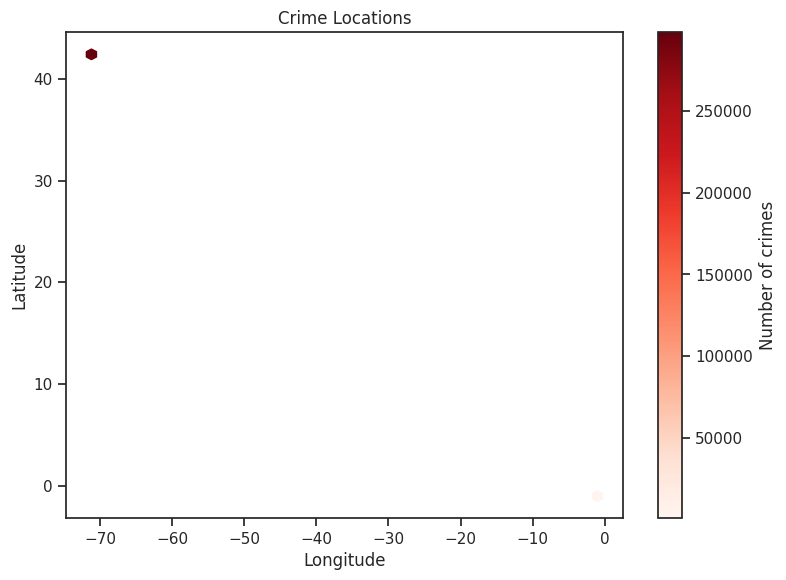

In [ ]:
plt.figure(figsize=(8,6))
plt.hexbin(crime['Long'], crime['Lat'], gridsize=50, cmap='Reds', mincnt=1)
plt.colorbar(label='Number of crimes')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Crime Locations')
plt.show()

In [ ]:
# Categorical columns constancy
for col in CAT:
    COUNT = crime[col].count()
    MAX_COUNTS = crime[col].value_counts().max() if COUNT != 0 else 0
    CONSTANCY = MAX_COUNTS / COUNT if COUNT != 0 else 0
    print(f"\nColumn: {col}")
    print("  Most frequent value frequency:", MAX_COUNTS)
    print("  Constancy:", CONSTANCY)


Column: INCIDENT_NUMBER
  Most frequent value frequency: 13
  Constancy: 4.074302745766643e-05

Column: OFFENSE_CODE_GROUP
  Most frequent value frequency: 37132
  Constancy: 0.11637462273523613

Column: OFFENSE_DESCRIPTION
  Most frequent value frequency: 18783
  Constancy: 0.05886740651825758

Column: DISTRICT
  Most frequent value frequency: 49945
  Constancy: 0.15740227160991843

Column: REPORTING_AREA
  Most frequent value frequency: 20250
  Constancy: 0.06346510046290348

Column: SHOOTING
  Most frequent value frequency: 1019
  Constancy: 1.0

Column: OCCURRED_ON_DATE
  Most frequent value frequency: 29
  Constancy: 9.088829202094818e-05

Column: DAY_OF_WEEK
  Most frequent value frequency: 48495
  Constancy: 0.1519871628122718

Column: UCR_PART
  Most frequent value frequency: 158553
  Constancy: 0.49705783693801864

Column: STREET
  Most frequent value frequency: 14194
  Constancy: 0.04605421119914861

Column: Location
  Most frequent value frequency: 19999
  Constancy: 0.0626


Pearson correlation:
               OFFENSE_CODE    YEAR      MONTH     HOUR       Lat      Long  
OFFENSE_CODE    1.000000    0.045103 -0.014322 -0.017036 -0.004569  0.003214
YEAR            0.045103    1.000000 -0.383351  0.001945 -0.015576  0.015375
MONTH          -0.014322   -0.383351  1.000000  0.002051 -0.004586  0.004695
HOUR           -0.017036    0.001945  0.002051  1.000000  0.007081 -0.007519
Lat            -0.004569   -0.015576 -0.004586  0.007081  1.000000 -0.999809
Long            0.003214    0.015375  0.004695 -0.007519 -0.999809  1.000000

Kendall correlation:
               OFFENSE_CODE    YEAR      MONTH     HOUR       Lat      Long  
OFFENSE_CODE    1.000000    0.031550 -0.007302 -0.017442 -0.050865 -0.017728
YEAR            0.031550    1.000000 -0.290971 -0.000005 -0.007816 -0.003823
MONTH          -0.007302   -0.290971  1.000000  0.001224  0.005415  0.000807
HOUR           -0.017442   -0.000005  0.001224  1.000000 -0.016409 -0.008223
Lat            -0.050865   -0.

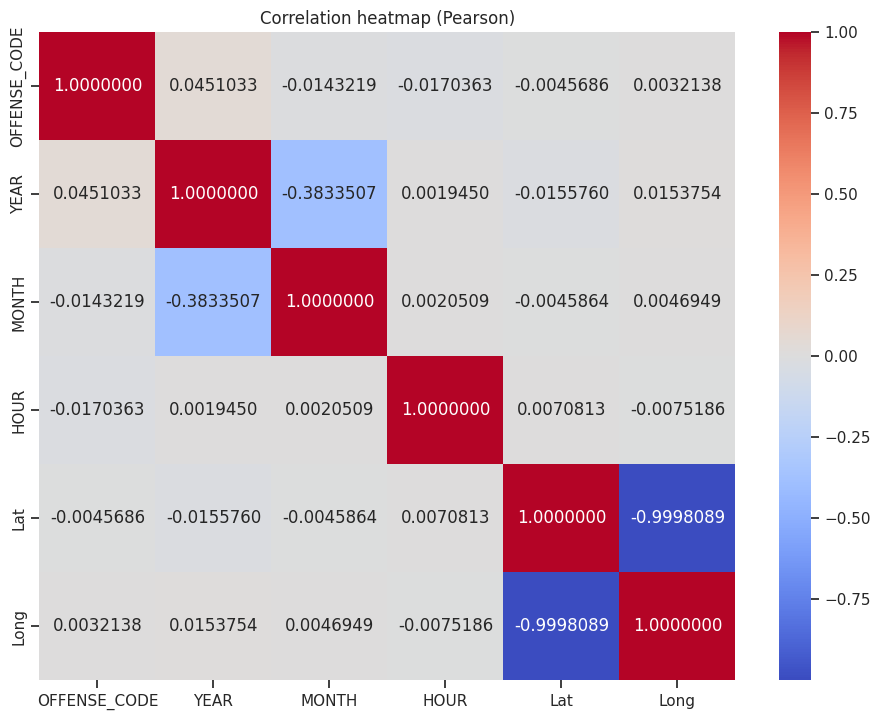

In [ ]:
# Correlations
if len(NUM) > 1:
    corr_pearson = crime[NUM].corr(method='pearson')
    corr_kendall = crime[NUM].corr(method='kendall')
    corr_spearman = crime[NUM].corr(method='spearman')

    print("\nPearson correlation:\n", corr_pearson)
    print("\nKendall correlation:\n", corr_kendall)
    print("\nSpearman correlation:\n", corr_spearman)

    # Heatmap
    plt.figure(figsize=(10,8))
    sns.heatmap(corr_pearson, annot=True, fmt=".7f", cmap='coolwarm')
    plt.title("Correlation heatmap (Pearson)")
    plt.show()

### YDATA-PROFILING LIBRARY

ydata_profiling is a useful library for building a profiling report. This library automatically generates a profile report from a pandas DataFrame for data understanding.

In [ ]:
profile = yp.ProfileReport(crime, title="Crime Dataset Profiling Report")
profile.to_file("crime_profile_report.html")
profile.to_file("crime_profile_report.json")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 17/17 [00:05<00:00,  2.86it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7c5824ed8e00> (for post_execute):


KeyboardInterrupt: 

In [ ]:
with open("crime_profile_report.json") as f:
    jfile = json.load(f)

missing_info = {col: jfile['variables'][col]['n_missing'] for col in jfile['variables'] if jfile['variables'][col]['n_missing'] > 0}
print("Columns with missing values:", missing_info)

alerts = jfile.get("alerts", [])
print("=== YData-Profiling Alerts ===")
for alert in alerts:
    print(f"- {alert}")

Columns with missing values: {'DISTRICT': 1765, 'SHOOTING': 318054, 'UCR_PART': 90, 'STREET': 10871, 'Lat': 19999, 'Long': 19999}
=== YData-Profiling Alerts ===
- [SHOOTING] has a constant value
- Dataset has 23 (< 0.1%) duplicate rows
- [SHOOTING] 318054 (99.7%) missing values
- [STREET] 10871 (3.4%) missing values
- [Lat] 19999 (6.3%) missing values
- [Long] 19999 (6.3%) missing values


1. **Columns with missing values**: STREET, DISTRICT, UCR_Part, location.
`SHOOTING` contains missing values, which likely indicate No.

2. **Value ranges / sets**: Mostly valid, except:

    a. Location has clear outliers (e.g., values instead of NaN or meaningful coordinates).

    b. Some strings have typos or possibly swapped descriptions in `crimes[OFFENSE_CODE_GROUP, OFFENSE_DESCRIPTION]` and `offense_codes[NAME]`.

    c. Typos in street names.


3. **Merge results**: Codes match correctly after merging.

4. **Duplicates**: There are repeated `INCIDENT_NUMBER` values.


# **2. DATA CLEANING**

In [ ]:
#helpers
def dq_assessment_table(df: pd.DataFrame) -> pd.DataFrame:
    """
    Pipeline-9-like DQ metrics:
    - Uniqueness   = distinct / rows
    - Distinctness = distinct / non-null count
    - Constancy    = max(freq) / non-null count
    - Completeness = non-null cells / total cells (global, repeated per row for convenience)
    """
    rows = len(df)
    total_cells = df.shape[0] * df.shape[1]
    not_null_cells = df.count().sum()
    completeness_global = (not_null_cells / total_cells) if total_cells else 0.0

    out = []
    for col in df.columns:
        count = df[col].count()
        distinct = df[col].nunique(dropna=True)
        uniqueness = distinct / rows if rows else 0.0
        distinctness = distinct / count if count else 0.0
        constancy = (df[col].value_counts(dropna=True).max() / count) if count else 0.0
        out.append({
            "column": col,
            "uniqueness": uniqueness,
            "distinctness": distinctness,
            "constancy": constancy,
            "completeness_global": completeness_global
        })
    return pd.DataFrame(out).sort_values("column")


def zscore_outliers(series: pd.Series, threshold: float = 3.0) -> pd.Index:
    """
    Return index of outliers using Z-score (Pipeline 9 uses ZS idea).
    Robustness: ignores NaNs; if std==0 returns empty.
    """
    s = pd.to_numeric(series, errors="coerce")
    mu = s.mean(skipna=True)
    sd = s.std(skipna=True)
    if pd.isna(sd) or sd == 0:
        return pd.Index([])
    z = (s - mu) / sd
    return s.index[z.abs() > threshold]


def normalize_street(s: object) -> object:
    """Light standardization (uppercase, remove punctuation, standard abbreviations)."""
    if pd.isna(s):
        return np.nan
    s = str(s).upper().strip()
    s = re.sub(r"[^\w\s]", " ", s)
    s = re.sub(r"\s+", " ", s)

    repl = {
        r"\bSTREET\b": "ST", r"\bROAD\b": "RD", r"\bAVENUE\b": "AVE",
        r"\bBOULEVARD\b": "BLVD", r"\bPLACE\b": "PL", r"\bSQUARE\b": "SQ",
        r"\bDRIVE\b": "DR", r"\bCOURT\b": "CT", r"\bHIGHWAY\b": "HWY"
    }
    for pat, rep in repl.items():
        s = re.sub(pat, rep, s)
    return s


def extract_coordinates(location_str: object):
    """
    Parse '(lat, long)' -> (lat, long). Returns (nan, nan) on failure.
    """
    if not isinstance(location_str, str):
        return (np.nan, np.nan)
    txt = location_str.strip()
    if "(" not in txt or ")" not in txt:
        return (np.nan, np.nan)
    try:
        a, b = txt.strip("()").split(",")
        return (float(a.strip()), float(b.strip()))
    except Exception:
        return (np.nan, np.nan)


## 2.1. Data transformation/standardization

In [ ]:
# Rename columns for clarity
# Rename all columns to a more consistent format

crime.rename(columns={
    'INCIDENT_NUMBER': 'Incident_ID',
    'OFFENSE_CODE': 'Offense_Code',
    'OFFENSE_CODE_GROUP': 'Crime_Type',
    'OFFENSE_DESCRIPTION': 'Crime_Description',
    'DISTRICT': 'District',
    'REPORTING_AREA': 'Reporting_Area',
    'SHOOTING': 'Shooting',
    'OCCURRED_ON_DATE': 'Date_Time',
    'YEAR': 'Year',
    'MONTH': 'Month',
    'DAY_OF_WEEK': 'Day_of_Week',
    'HOUR': 'Hour',
    'UCR_PART': 'UCR_Part',
    'STREET': 'Street',
    'Lat': 'Latitude',
    'Long': 'Longitude',
    'Location': 'Location_Coordinates'
}, inplace=True)

print("Columns after renaming:")
print(crime.columns)

Columns after renaming:
Index(['Incident_ID', 'Offense_Code', 'Crime_Type', 'Crime_Description',
       'District', 'Reporting_Area', 'Shooting', 'Date_Time', 'Year', 'Month',
       'Day_of_Week', 'Hour', 'UCR_Part', 'Street', 'Latitude', 'Longitude',
       'Location_Coordinates'],
      dtype='object')


In [ ]:
# Standardize types / formats
crime["Date_Time"] = pd.to_datetime(crime["Date_Time"], errors="coerce")

In [ ]:
# New feature "Is_holiday"
us_holidays = holidays.US()

crime["Is_holiday"] = crime["Date_Time"].dt.date.apply(
    lambda x: x in us_holidays
)

In [ ]:
# Ensure numeric columns are numeric
for c in ["Year", "Month", "Hour", "Offense_Code", "Reporting_Area"]:
    if c in crime.columns:
        crime[c] = pd.to_numeric(crime[c], errors="coerce")

In [ ]:
# Normalize categorical text
if "Day_of_Week" in crime.columns:
    crime["Day_of_Week"] = crime["Day_of_Week"].astype(str).str.strip().str.title().replace({"Nan": np.nan})

if "UCR_Part" in crime.columns:
    crime["UCR_Part"] = crime["UCR_Part"].astype(str).str.strip().replace({"nan": np.nan, "Nan": np.nan})

if "District" in crime.columns:
    crime["District"] = crime["District"].astype(str).str.strip().str.upper().replace({"NAN": np.nan})

if "Street" in crime.columns:
    crime["Street"] = crime["Street"].apply(normalize_street)

In [ ]:
# Standardize Location -> (Latitude, Longitude) when missing
tmp_latlong = crime["Location_Coordinates"].apply(extract_coordinates)
crime["Loc_Lat"] = tmp_latlong.apply(lambda x: x[0])
crime["Loc_Long"] = tmp_latlong.apply(lambda x: x[1])

crime["Latitude"] = crime["Latitude"].fillna(crime["Loc_Lat"])
crime["Longitude"] = crime["Longitude"].fillna(crime["Loc_Long"])


In [ ]:
# Drop temp helper cols for transformation step (we re-check consistency later if needed)
crime.drop(columns=["Loc_Lat", "Loc_Long"], inplace=True)


In [ ]:
# Convert obvious placeholders to NaN (common in this dataset)
invalid_loc_str = {"(0.00000000, 0.00000000)", "(-1.00000000, -1.00000000)"}
crime.loc[crime["Location_Coordinates"].astype(str).isin(invalid_loc_str), "Location_Coordinates"] = np.nan


In [ ]:
# Mark invalid numeric coordinates as NaN (0/-1 often used as placeholders)
invalid_coord_mask = (
    crime["Latitude"].isin([0, -1]) |
    crime["Longitude"].isin([0, -1])
)
crime.loc[invalid_coord_mask, ["Latitude", "Longitude"]] = np.nan


In [ ]:
crime_dirty = crime.copy()
crime_knn  = crime.copy()

### Detecting and correcting typos

1. **Normalization**: e.g. domain-specific abbreviation mappings.
2. **Clustering similar strings**:
    - All unique normalized strings are compared using fuzzy string similarity (`fuzz.token_sort_ratio`).
    - Strings that are similar above a specified threshold (e.g., 90%) are grouped into clusters.
3. **Correcting rare variants**:
    - For each cluster, the most common string is identified.
    - Variants that occur rarely (≤ rare_count) are replaced with the most common value.

In [ ]:
def normalize_string(s):
    if pd.isna(s):
        return None
    s = s.lower()
    s = re.sub(r'[^\w\s]', '', s)
    s = re.sub(r'\s+', ' ', s)
    return s.strip()

STREET_ABBREVIATIONS = {
    r"\bst\b": "street",
    r"\brd\b": "road",
    r"\bave\b": "avenue",
    r"\bav\b": "avenue",
    r"\bblvd\b": "boulevard",
    r"\bbl\b": "boulevard",
    r"\bct\b": "court",
    r"\bter\b": "terrace",
    r"\bpl\b": "place",
    r"\bplz\b": "plaza",
    r"\bpkwy\b": "parkway",
    r"\bhwy\b": "highway",
    r"\bsq\b": "square",
    r"\bpk\b": "park",
    r"\bwhrf\b": "wharf",
    r"\bwharf\b": "wharf",
    r"\bpub\b": "public"
}

DIRECTION_MAP = {
    r"\bn\b": "north",
    r"\bs\b": "south",
    r"\be\b": "east",
    r"\bw\b": "west"
}

def normalize_street(s):
    if pd.isna(s):
        return None

    s = s.lower()

    # Remove house numbers (e.g. "5 beacon st" → "beacon st")
    s = re.sub(r"^\d+\s+", "", s)

    # Remove punctuation
    s = re.sub(r"[^\w\s]", " ", s)

    # Normalize directions
    for pattern, repl in DIRECTION_MAP.items():
        s = re.sub(pattern, repl, s)

    # Normalize street abbreviations
    for pattern, repl in STREET_ABBREVIATIONS.items():
        s = re.sub(pattern, repl, s)

    # Collapse multiple spaces
    s = re.sub(r"\s+", " ", s)

    return s.strip()

CRIME_ABBREVIATIONS = {
    r"\bb&e\b": "burglary",
    r"\bnon residence day\b": "commercial",
    r"\bresidential\b": "residence day",
    r"\battempt force\b": "attempt",
    r"\bforcible\b": "force",
    r"\ba&b\b": "assault and battery",
    r"\bcont sub\b": "controlled substance",
    r"\bviol\.\b": "violation",
    r"\bthe\b": ""
}

def normalize_crime_description(s):
    """
    Normalize crime description:
    - lowercase
    - remove punctuation
    - apply abbreviation mapping
    - collapse spaces
    """
    if pd.isna(s):
        return None

    s = s.lower()

    # Remove punctuation
    s = re.sub(r"[^\w\s]", " ", s)

    # Apply replacements from the mapping
    for pattern, repl in CRIME_ABBREVIATIONS.items():
        s = re.sub(pattern, repl, s)

    # Collapse multiple spaces
    s = re.sub(r"\s+", " ", s)

    return s.strip()

In [ ]:
def cluster_similar_strings(
    series,
    threshold=90
):

    values = series.dropna().unique()
    values = sorted(values)

    clusters = []

    for value in values:
        found_cluster = False

        for cluster in clusters:
            if fuzz.token_sort_ratio(value, cluster[0]) >= threshold:
                cluster.append(value)
                found_cluster = True
                break

        if not found_cluster:
            clusters.append([value])

    return {i: cluster for i, cluster in enumerate(clusters)}

def build_clusters_for_column(df, column, threshold=90):
    series = df[column].apply(normalize_string)
    clusters = cluster_similar_strings(series, threshold)
    return clusters

def show_non_trivial_clusters(clusters):
    return {
        cid: values
        for cid, values in clusters.items()
        if len(values) > 1
    }

def correct_typos(
    df,
    column,
    threshold=90,
    rare_count=2,
    exclude_contains=None,  # string or list of substrings to exclude from normalization
    normalize_func=None     # custom normalization function
):
    """
    Correct rare variations in a text column based on clustering similar strings.

    Parameters:
    - df: pandas.DataFrame
    - column: str, name of the column to normalize and correct
    - threshold: int, similarity threshold for clustering (0-100)
    - rare_count: int, if a variant occurs <= rare_count times in a cluster, it will be replaced
    - exclude_contains: str or list of substrings; rows containing these will be excluded
    - normalize_func: function, optional custom function to normalize strings

    Returns:
    - df: DataFrame with 3 new columns:
        * <column>_NORM: normalized version of the original column
        * <column>_FIXED: corrected values
        * <column>_STATUS: 'changed' or 'unchanged'
    """
    df = df.copy()

    # Use provided normalization function, else use default
    if normalize_func is None:
        normalize_func = normalize_string

    # Normalize the column
    df[f"{column}_NORM_ORIG"] = df[column].apply(normalize_func)
    df[f"{column}_NORM"] = df[f"{column}_NORM_ORIG"]

    # Exclude rows containing specified substrings
    mask_exclude = []
    if exclude_contains is not None:
        if isinstance(exclude_contains, str):
            exclude_contains = [exclude_contains]
        mask_exclude = df[f"{column}_NORM"].apply(
            lambda x: any(substr in x for substr in exclude_contains) if pd.notna(x) else False
        )
        df.loc[mask_exclude, f"{column}_NORM"] = None

    # Build clusters of similar strings
    clusters = build_clusters_for_column(df, f"{column}_NORM", threshold)
    clusters = show_non_trivial_clusters(clusters)

    corrections = {}
    total_clusters = len(clusters)

    # Iterate through each cluster
    for i, (cluster_id, variants) in enumerate(clusters.items(), 1):
        print(f"Processing cluster {i}/{total_clusters}: {variants}")

        cluster_rows = df[df[f"{column}_NORM"].isin(variants)]

        # Count occurrences of each variant
        value_counts = cluster_rows[f"{column}_NORM"].value_counts()
        # if value_counts.empty:
        #   continue
        most_common = value_counts.idxmax()

        # Correct rare variants
        for idx, row in cluster_rows.iterrows():
            count = value_counts[row[f"{column}_NORM"]]

            if pd.isna(row[f"{column}_NORM"]):
                corrections[idx] = most_common
            elif count <= rare_count and row[f"{column}_NORM"] != most_common:
                corrections[idx] = most_common
                print("Changed: ", row[f"{column}_NORM"], "->", most_common)
            else:
                corrections[idx] = row[f"{column}_NORM"]

    # Apply corrections
    df[f"{column}_FIXED"] = df[f"{column}_NORM"]
    for idx, value in corrections.items():
        df.at[idx, f"{column}_FIXED"] = value

    # For excluded rows: put back their original normalized values
    df.loc[mask_exclude, f"{column}_FIXED"] = df.loc[mask_exclude, f"{column}_NORM_ORIG"]

    # Status: changed or unchanged
    df[f"{column}_STATUS"] = df.apply(
        lambda x: "changed" if x[f"{column}_NORM"] != x[f"{column}_FIXED"] else "unchanged",
        axis=1
    )

    return df

In [ ]:
crime_fixed = correct_typos(
    crime,
    column="Street",
    threshold=93,
    rare_count=1,
    exclude_contains=["public alley no", "alder street", "atlantis street"],
    normalize_func=normalize_street
)

Processing cluster 1/132: ['acadia street', 'arcadia street']
Processing cluster 2/132: ['acorn street', 'alcorn street']
Processing cluster 3/132: ['aguadilla street', 'aquadilla street']
Changed:  aquadilla street -> aguadilla street
Processing cluster 4/132: ['alaska street', 'alaska stret']
Changed:  alaska stret -> alaska street
Processing cluster 5/132: ['alban street', 'albano street', 'albany street']
Processing cluster 6/132: ['albert street', 'alberta street']
Processing cluster 7/132: ['allstae', 'allstate']
Changed:  allstae -> allstate
Processing cluster 8/132: ['ames street', 'street james']
Changed:  street james -> ames street
Processing cluster 9/132: ['amory street', 'armory street']
Processing cluster 10/132: ['anson street', 'hanson street']
Processing cluster 11/132: ['anthony rip valenti wa', 'anthony rip valenti way']
Processing cluster 12/132: ['appleton street', 'mapleton street']
Processing cluster 13/132: ['arch street', 'larch street']
Processing cluster 14/

In the Street column, rare typos like "alaska stret" were corrected to "alaska street".

In [ ]:
crime["Street"] = crime_fixed["Street_FIXED"]

In [ ]:
crime_fixed = correct_typos(
    crime,
    column="Crime_Type",
    threshold=70,
    rare_count=1
)

Processing cluster 1/5: ['commercial burglary', 'other burglary']
Processing cluster 2/5: ['drug violation', 'liquor violation', 'violations']
Processing cluster 3/5: ['investigate person', 'investigate property']
Processing cluster 4/5: ['license plate related incidents', 'prisoner related incidents']
Processing cluster 5/5: ['property found', 'property lost']


For Crime_Type, no changes were necessary, which confirms that the parameters were chosen to avoid overcorrecting.

In [ ]:
crime["Crime_Type"] = crime_fixed["Crime_Type_FIXED"]

In [ ]:
crime_fixed = correct_typos(
    crime,
    column="Crime_Description",
    threshold=90,
    rare_count=1,
    exclude_contains=["class d"],
    normalize_func=normalize_crime_description
)

Processing cluster 1/14: ['annoying and accostin', 'annoying and accosting']
Changed:  annoying and accostin -> annoying and accosting
Processing cluster 2/14: ['auto theft lease rent vehicle', 'auto theft leased rented vehicle']
Changed:  auto theft lease rent vehicle -> auto theft leased rented vehicle
Processing cluster 3/14: ['b e commercial force', 'b e commercial no force']
Processing cluster 4/14: ['burglary commerical force', 'burglary commerical no force']
Processing cluster 5/14: ['burglary other force', 'burglary other no force']
Processing cluster 6/14: ['burglary residence day force', 'burglary residence day no force']
Processing cluster 7/14: ['drugs class a trafficking over 18 grams', 'drugs class b trafficking over 18 grams']
Processing cluster 8/14: ['drugs poss class a intent to mfr dist disp', 'drugs poss class b intent to mfr dist disp', 'drugs poss class c intent to mfr dist disp', 'drugs poss class e intent to mf dist disp', 'drugs poss class e intent to mfr dist 

In Crime_Description, for example, "annoying and accostin" was corrected to "annoying and accosting".

In [ ]:
crime["Crime_Description"] = crime_fixed["Crime_Description_FIXED"]

In [ ]:
codes_fixed = correct_typos(
    offense_codes,
    column="NAME",
    threshold=97,
    rare_count=2,
    exclude_contains=["class d", "class c", "class b", "class e", "b e non residence night force", "killing of police by felon"],
    normalize_func=normalize_crime_description
)

Processing cluster 1/5: ['annoying and accostin', 'annoying and accosting']
Changed:  annoying and accostin -> annoying and accosting
Processing cluster 2/5: ['assault simple', 'simple assault']
Changed:  simple assault -> assault simple
Processing cluster 3/5: ['criminal harassment', 'criminal harrassment']
Changed:  criminal harrassment -> criminal harassment
Processing cluster 4/5: ['drugs sick assist other narcotic', 'drugs sick assist other narcotics']
Changed:  drugs sick assist other narcotics -> drugs sick assist other narcotic
Processing cluster 5/5: ['m v accident other city vehicle', 'm v acciident other city vehicle']
Changed:  m v acciident other city vehicle -> m v accident other city vehicle


Example: annoying and accostin -> annoying and accosting

In [ ]:
offense_codes["NAME"] = codes_fixed["NAME_FIXED"]

## 2.2. Error detection and correction

### 2.2.1 Missing values

In [ ]:
# Missing Lat/Long from Location_Coordinates again (in case Location exists but lat/long still NaN)
tmp_latlong = crime["Location_Coordinates"].apply(extract_coordinates)
tmp_lat = tmp_latlong.apply(lambda x: x[0])
tmp_long = tmp_latlong.apply(lambda x: x[1])

crime["Latitude"] = crime["Latitude"].fillna(tmp_lat)
crime["Longitude"] = crime["Longitude"].fillna(tmp_long)

In [ ]:
# Plausibility bounds for Boston (soft rule): out-of-bounds -> NaN (then imputable)
boston_lat_ok = crime["Latitude"].between(42.2279, 42.3967)
boston_long_ok = crime["Longitude"].between(-71.1912, -70.9860)
crime.loc[~(boston_lat_ok & boston_long_ok), ["Latitude", "Longitude"]] = np.nan

### Shooting NaN values

1. Original data has only Y and NaN values.

1. Checked dependence on Year → negligible effect (Pseudo R² ≈ 0), so missingness is not time-related.

2. Checked dependence on  Crime type → strong correlation.

**Conclusion**: Missing values can be replaced with N (no shooting).




In [ ]:
crime["Shooting"] = crime["Shooting"].fillna("Unknown")

In [ ]:
tmp = crime.assign(
    is_unknown=crime["Shooting"].eq("Unknown").astype(int),
    is_y=crime["Shooting"].eq("Y").astype(int)
)

year_stats = (
    tmp
    .groupby("Year", observed=True)
    .agg(
        is_unknown_rate=("is_unknown", "mean"),
        is_y_rate=("is_y", "mean")
    )
)

year_stats

Button(description='Toggle Pandas/Lux', layout=Layout(top='5px', width='140px'), style=ButtonStyle())

Output()

In [ ]:
df = crime.dropna(subset=["Shooting"]).copy()
df["is_y"] = (df["Shooting"] == "Y").astype(int)

X = sm.add_constant(df["Year"])
y = df["is_y"]

model = sm.Logit(y.values, X).fit(disp=False)
print(model.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:               319073
Model:                          Logit   Df Residuals:                   319071
Method:                           MLE   Df Model:                            1
Date:                Mon, 05 Jan 2026   Pseudo R-squ.:               1.902e-05
Time:                        13:05:25   Log-Likelihood:                -6873.0
converged:                       True   LL-Null:                       -6873.2
Covariance Type:            nonrobust   LLR p-value:                    0.6091
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         26.7185     63.484      0.421      0.674     -97.707     151.144
x1            -0.0161      0.031     -0.511      0.609      -0.078       0.046


The effect size is negligible (Pseudo R² ≈ 0), so in practice, the year has almost no impact on whether a crime involves a shooting.

In [ ]:
contingency = (
    crime
    .groupby(["UCR_Part", "Shooting"])
    .size()
    .unstack(fill_value=0)
)

contingency

Shooting,Unknown,Y
UCR_Part,,
Other,1231,1
Part One,60966,663
Part Three,158387,166
Part Two,97385,184


In [ ]:
chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.4e}")

Chi-square statistic: 1398.27
Degrees of freedom: 3
P-value: 7.0082e-303


A chi-square test of independence indicates a statistically significant association between UCR_Part and Shooting.
A chi-square test of independence indicates a statistically significant association between UCR_Part and Shooting

In [ ]:
crime.pivot_table(
    index="Crime_Type",
    columns="Shooting",
    aggfunc="size",
    fill_value=0
)

Button(description='Toggle Pandas/Lux', layout=Layout(top='5px', width='140px'), style=ButtonStyle())

Output()

In [ ]:
# Pivot table / contingency table
contingency = crime.pivot_table(
    index="Crime_Type",
    columns="Shooting",
    aggfunc="size",
    fill_value=0
)

print("Contingency table (first 5 rows):")
print(contingency.head())

# Chi-square test of independence
chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f"\nChi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.4e}")

# Standardized residuals (optional, to see which Crime_Type contributes most)
residuals = (contingency - expected) / np.sqrt(expected)
print("\nStandardized residuals (first 5 rows):")
print(residuals.head())

# Effect size — Cramér’s V
n = contingency.values.sum()
k = min(contingency.shape) - 1
cramers_v = np.sqrt(chi2 / (n * k))
print(f"\nCramér's V (effect size): {cramers_v:.3f}")

Contingency table (first 5 rows):
Shooting                          Unknown   Y 
Crime_Type                                    
aggravated assault                 7284    523
aircraft                             36      0
arson                                94      0
assembly or gathering violations    955      0
auto theft                         4851      0

Chi-square statistic: 40692.55
Degrees of freedom: 65
P-value: 0.0000e+00

Standardized residuals (first 5 rows):
Shooting                           Unknown      Y    
Crime_Type                                           
aggravated assault               -5.645996  99.747938
aircraft                          0.019192  -0.339073
arson                             0.031013  -0.547906
assembly or gathering violations  0.098851  -1.746400
auto theft                        0.222789  -3.936024

Cramér's V (effect size): 0.357


The chi-square test shows a highly significant association between Crime_Type and Shooting (χ² = 40692.55, p < 0.0001).
The chi-square test shows a highly significant association between Crime_Type and Shooting (χ² = 40692.55, p < 0.0001).

In [ ]:
# Missing values: domain rule
crime["Shooting"] = crime["Shooting"].astype(str).str.strip().str.upper().replace({"NAN": "N"})
crime.loc[~crime["Shooting"].isin(["Y", "N"]), "Shooting"] = "N"

### UCR_Part imputation

1. Fill missing UCR_Part values using the most frequent UCR_Part
for the same Offense_Code (It's checked that Offense_Code -> UCR_Part).

In [ ]:
# @title
# Drop rows with missing values in relevant columns
crime_filtered = crime.dropna(subset=["Offense_Code", "UCR_Part"])

# Define a function to identify groups with more than one unique UCR_Part
def has_multiple_ucr_parts(group):
    return group["UCR_Part"].nunique() > 1

# Filter the DataFrame to keep only rows belonging to inconsistent groups
inconsistent_data = crime_filtered.groupby("Offense_Code").filter(has_multiple_ucr_parts)

# Now, group the inconsistent data to show the unique UCR_Part for each inconsistent Offense_Code
inconsistent_codes = inconsistent_data.groupby("Offense_Code")["UCR_Part"].unique()

# Display results
print("Offense_Codes with inconsistent UCR_Part:")
print(inconsistent_codes)

Offense_Codes with inconsistent UCR_Part:
LuxSeries([], Name: UCR_Part, dtype: object)


In [ ]:
def fill_missing_ucr(crime_filled):
    """
    Fill missing UCR_Part values using the most frequent UCR_Part
    for the same Offense_Code.
    """

    # Only consider rows where UCR_Part is not missing
    valid_rows = crime_filled[crime_filled["UCR_Part"].notna()]

    # Group by Offense_Code
    for code, group in valid_rows.groupby("Offense_Code"):
        # Get the most frequent UCR_Part (mode)
        mode_value = group["UCR_Part"].mode()
        if not mode_value.empty:
            most_common = mode_value.iloc[0]
            # Fill missing values for this Offense_Code
            mask = (crime_filled["Offense_Code"] == code) & (crime_filled["UCR_Part"].isna())
            crime_filled.loc[mask, "UCR_Part"] = most_common

    return crime_filled

In [ ]:
crime= fill_missing_ucr(crime)

2. UCR_Part is a crime classification => learn a ml-imputer (lightgbm) on "Crime_Type", "Crime_Description", "Offense_Code".

In [ ]:
# @title
def train_ucr_imputer(df, text_features, cat_features, target="UCR_Part", random_state=42):
    """
    Train a LightGBM classifier to impute missing UCR_Part values
    using text and categorical features.

    Parameters:
    - df: DataFrame with missing target values
    - text_features: list of text columns
    - cat_features: list of categorical columns
    - target: target column (default 'UCR_Part')
    """
    # Split rows with known target vs missing target
    df_known = df[df[target].notna()].copy()
    df_missing = df[df[target].isna()].copy()

    # Encode target
    target_encoder = LabelEncoder()
    y_known = target_encoder.fit_transform(df_known[target])

    # Preprocessing for text features: TF-IDF
    text_transformers = [(col, TfidfVectorizer(max_features=1000), col) for col in text_features]

    # Preprocessing for categorical features: OneHot + imputer
    cat_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=text_transformers + [("cat", cat_transformer, cat_features)],
        remainder="drop"
    )

    # Build the pipeline
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", lgb.LGBMClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=-1,
            random_state=random_state,
            n_jobs=-1
        ))
    ])

    # Split for evaluation
    X_train, X_test, y_train, y_test = train_test_split(
        df_known[text_features + cat_features],
        y_known,
        test_size=0.2,
        random_state=random_state,
        stratify=y_known
    )

    # Fit model
    pipe.fit(X_train, y_train)

    # Evaluate
    y_pred = pipe.predict(X_test)
    print("Classification report on known UCR_Part rows:")
    print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

    # Impute missing rows
    if not df_missing.empty:
        df_missing[target] = target_encoder.inverse_transform(
            pipe.predict(df_missing[text_features + cat_features])
        )

    # Combine data back
    df_imputed = pd.concat([df_known, df_missing], ignore_index=True)

    return df_imputed, pipe, target_encoder

In [ ]:
text_features = ["Crime_Type", "Crime_Description"]
cat_features = ["Offense_Code"]

crime, lgb_pipe, ucr_encoder = train_ucr_imputer(crime, text_features, cat_features)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.043670 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1406
[LightGBM] [Info] Number of data points in the train set: 255189, number of used features: 510
[LightGBM] [Info] Start training from score -5.556103
[LightGBM] [Info] Start training from score -1.644020
[LightGBM] [Info] Start training from score -0.699039
[LightGBM] [Info] Start training from score -1.184591
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

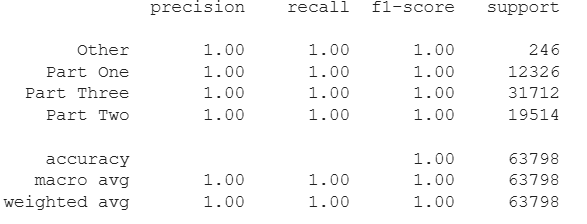

In [ ]:
crime['UCR_Part'].isna().sum()

np.int64(0)

### District, Reporting_Area, and Street imputation

1. Fill missing values for District, Reporting_Area, and Street sequentially, using the most frequent value among rows with the same Location_Coordinates.

In [ ]:
def fill_missing_by_coordinates(df, columns_to_fill=['District', 'Reporting_Area', 'Street'], coord_col='Location_Coordinates'):
    """
    Fill missing values in specified columns using the most frequent value among rows
    with the same coordinates.

    Parameters:
    - df: pandas.DataFrame
    - columns_to_fill: list of columns to fill if missing
    - coord_col: column containing coordinates

    Returns:
    - df_filled: DataFrame with missing values filled where possible
    """
    df = df.copy()

    # Iterate over rows with missing values in any of the columns_to_fill
    mask_missing = df[columns_to_fill].isna().any(axis=1)
    rows_missing = df[mask_missing]

    for idx, row in rows_missing.iterrows():
        coord = row[coord_col]

        if pd.isna(coord):
            continue

        # Get all rows with same coordinates, where the column is not missing
        duplicates = df[df[coord_col] == coord]

        for col in columns_to_fill:
            if pd.isna(row[col]):
                # Get the most common non-missing value in this column for this coordinate
                non_missing_vals = duplicates[col].dropna()
                if not non_missing_vals.empty:
                    most_common_val = non_missing_vals.mode()[0]
                    df.at[idx, col] = most_common_val

    return df

In [ ]:
crime = fill_missing_by_coordinates(crime)

2. District, Reporting_Area, Street depend only on the location => we can do imputation with k-nearest neighbors using coordinates.

In [ ]:
# @title
def impute_by_coordinates(df, target_cols, coord_cols=["Latitude", "Longitude"], n_neighbors=5):
    """
    Impute missing categorical values based on nearest neighbors using coordinates.

    Parameters:
    - df: DataFrame
    - target_cols: list of columns to impute (categorical)
    - coord_cols: list of coordinate columns (default ["Latitude", "Longitude"])
    - n_neighbors: number of neighbors for KNN
    """
    df = df.copy()
    encoders = {}
    models = {}

    for col in target_cols:
        # Only rows with non-missing target and coordinates
        known_mask = df[col].notna() & df[coord_cols].notna().all(axis=1)
        missing_mask = df[col].isna() & df[coord_cols].notna().all(axis=1)

        if known_mask.sum() == 0:
            print(f"No known values for {col}, skipping imputation.")
            continue

        # Encode target
        le = LabelEncoder()
        y_known = le.fit_transform(df.loc[known_mask, col])
        encoders[col] = le

        # Train KNN on coordinates
        knn = KNeighborsClassifier(n_neighbors=n_neighbors)
        knn.fit(df.loc[known_mask, coord_cols], y_known)

        # Predict missing values
        df.loc[missing_mask, col] = le.inverse_transform(
            knn.predict(df.loc[missing_mask, coord_cols])
        )

        models[col] = knn

        print(f"Imputed {missing_mask.sum()} missing values for {col}.")

    return df, encoders, models


In [ ]:
target_columns = ["District", "Reporting_Area", "Street"]
crime, encoders_coords, street_imputers = impute_by_coordinates(crime, target_columns)

Imputed 834 missing values for District.
Imputed 1986 missing values for Reporting_Area.
Imputed 1781 missing values for Street.


In [ ]:
crime[["District", "Reporting_Area", "Street"]].isna().sum()

,0
District,868
Reporting_Area,18169
Street,9090


### Сoordinates imputation

Impute coordinates using Street median, else Reporting_Area median, else District median

In [ ]:
def impute_coords_by_group(df, group_col):
    pdf = pd.DataFrame(df)

    medians = (
        pdf
        .dropna(subset=["Latitude", "Longitude"])
        .groupby(group_col)[["Latitude", "Longitude"]]
        .median()
    )

    # masks
    missing_lat = df["Latitude"].isna()
    missing_lon = df["Longitude"].isna()
    has_group = df[group_col].notna()

    # Latitude
    idx_lat = df[missing_lat & has_group].index
    df.loc[idx_lat, "Latitude"] = df.loc[idx_lat, group_col].map(medians["Latitude"])

    # Longitude
    idx_lon = df[missing_lon & has_group].index
    df.loc[idx_lon, "Longitude"] = df.loc[idx_lon, group_col].map(medians["Longitude"])

    return df

In [ ]:
crime = impute_coords_by_group(crime, "Street")
crime = impute_coords_by_group(crime, "Reporting_Area")
crime = impute_coords_by_group(crime, "District")

In [ ]:
crime[["Latitude", "Longitude"]].isna().sum()

,0
Latitude,18263
Longitude,18263


Repeat "District", "Reporting_Area", "Street" imputation for new coordinates.

In [ ]:
coord_cols = ["Latitude", "Longitude"]
target_columns = ["District", "Reporting_Area", "Street"]

for col in target_columns:

    missing_mask = crime[col].isna() & crime[coord_cols].notna().all(axis=1)

    if missing_mask.sum() == 0:
        print(f"No missing values with coordinates for {col}, skipping...")
        continue

    # Predict missing values
    crime.loc[missing_mask, col] = encoders_coords[col].inverse_transform(
        street_imputers[col].predict(crime.loc[missing_mask, coord_cols])
    )

    print(f"Imputed {missing_mask.sum()} missing values for {col}.")


Imputed 10 missing values for District.
No missing values with coordinates for Reporting_Area, skipping...
Imputed 857 missing values for Street.


In [ ]:
print(crime.isna().sum())

Incident_ID                 0
Offense_Code                0
Crime_Type                  0
Crime_Description           0
District                  858
Reporting_Area          18169
Shooting                    0
Date_Time                   0
Year                        0
Month                       0
Day_of_Week                 0
Hour                        0
UCR_Part                    0
Street                   8233
Latitude                18263
Longitude               18263
Location_Coordinates    20744
Is_holiday                  0
dtype: int64


<Axes: >

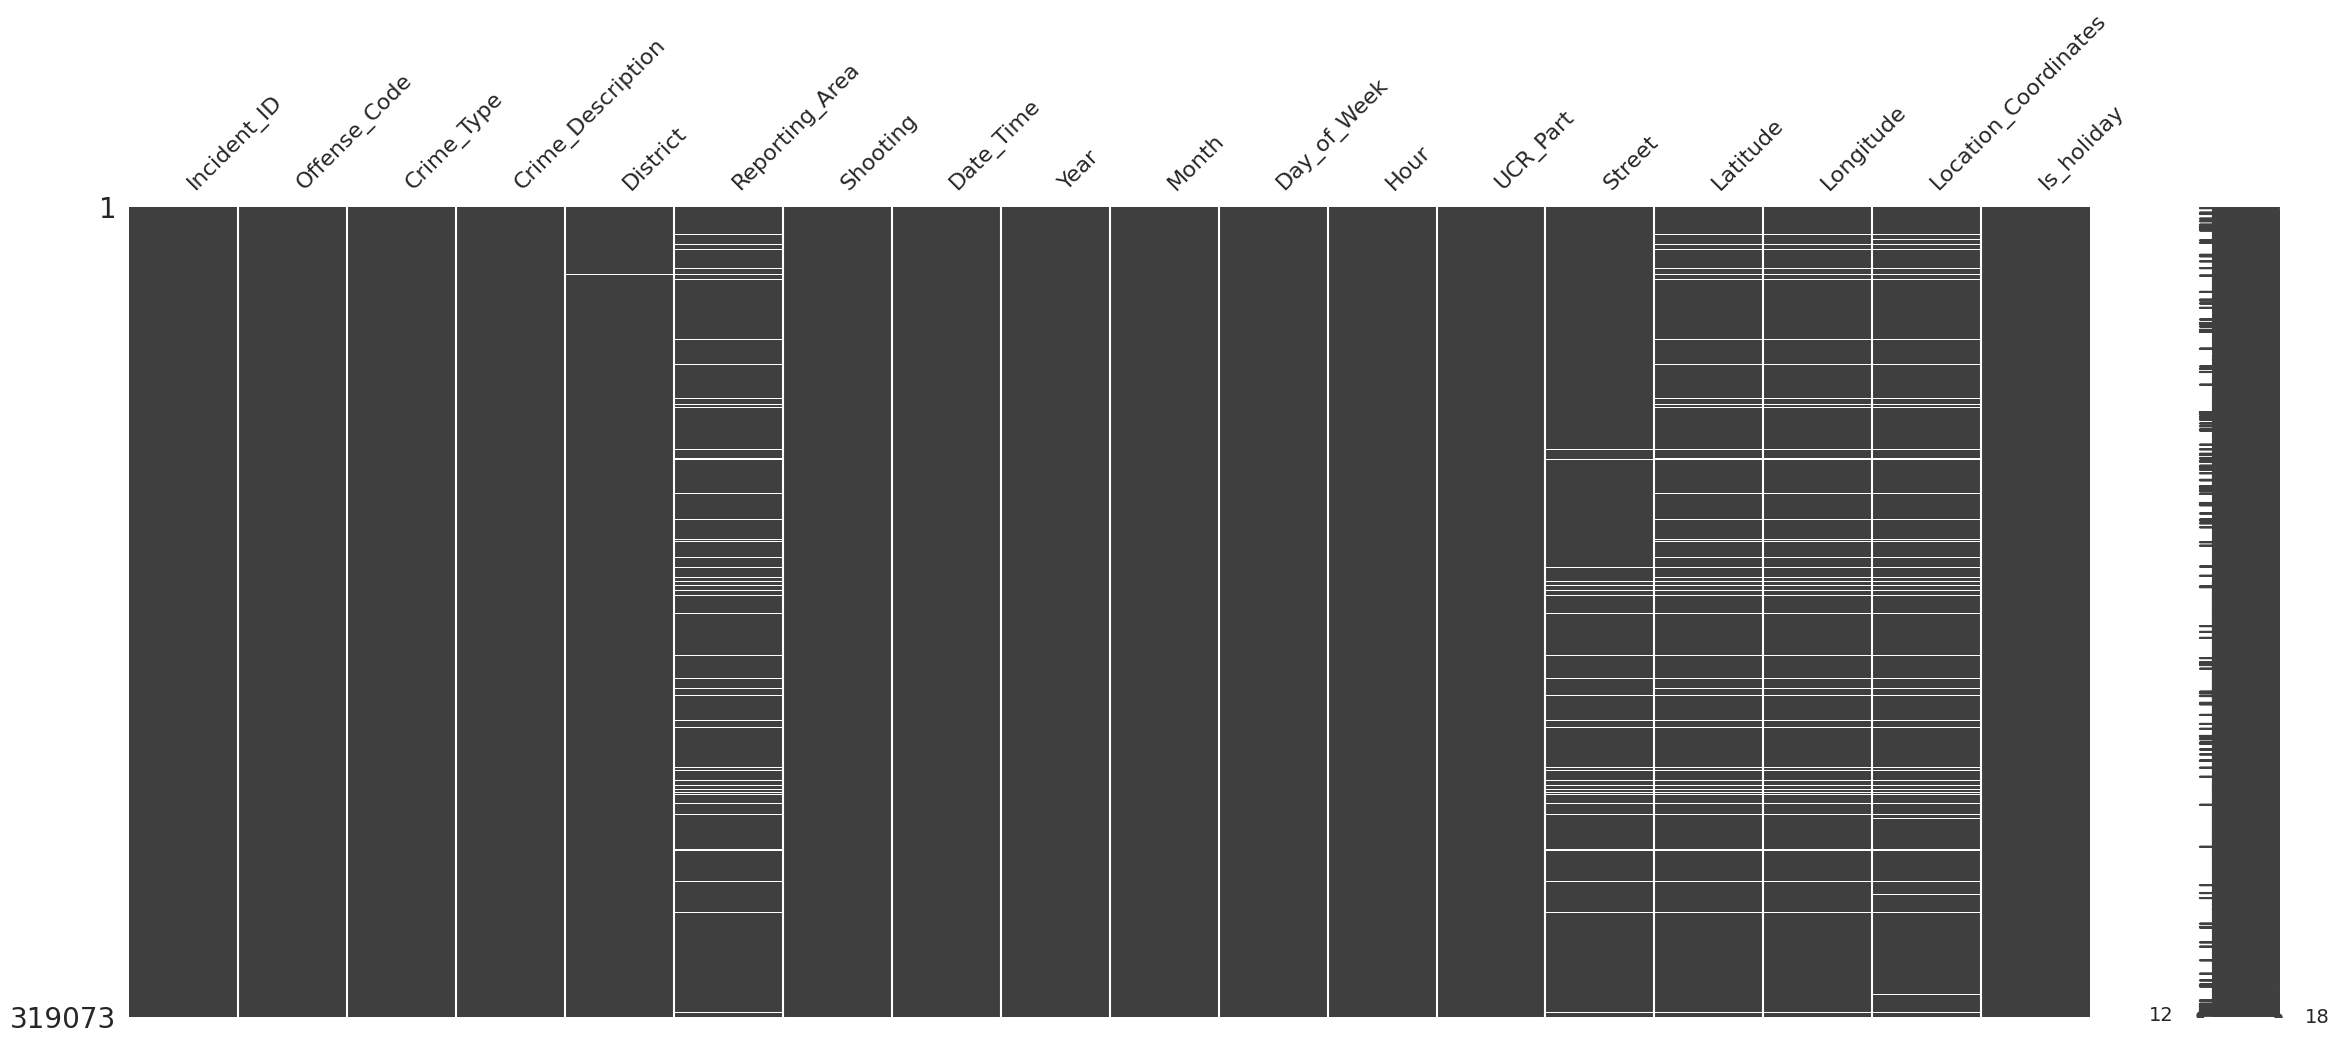

In [ ]:
mno.matrix(crime)

### MICE for numerical columns

At this stage, most of the missing values cannot be filled by simple rules or exact matches—for example, using coordinates or other direct relationships—because the remaining data is too ambiguous.

Therefore, we move to **Multiple Imputation by Chained Equations (MICE)**. This approach allows us to predict and fill the remaining missing values by leveraging all other available features, including those that do not have a direct one-to-one relationship with the target columns.

In [ ]:
# Columns to impute
target_cols = ["District", "Reporting_Area", "Street", "Latitude", "Longitude"]

# Features to use
feature_cols = ["Offense_Code", "Crime_Type", "Crime_Description",
                "Year", "Month", "Day_of_Week", "Hour", "Shooting"]

# Prepare a copy of data
df_impute = crime[target_cols + feature_cols].copy()

# Encode categorical columns
encoders = {}
for col in ["District", "Street", "Offense_Code", "Crime_Type", "Crime_Description", "Shooting", "Day_of_Week"]:
    le = LabelEncoder()
    #df_impute[col] = df_impute[col].astype(str)  # convert nan to string if needed
    df_impute[col] = le.fit_transform(df_impute[col])
    encoders[col] = le

# MICE
imputer = IterativeImputer(
    estimator=DecisionTreeRegressor(),
    max_iter=5,
    random_state=42
)

imputed_array = imputer.fit_transform(df_impute)
imputed_df = pd.DataFrame(imputed_array, columns=df_impute.columns)

# Decode categorical columns back
for col in encoders:
    imputed_df[col] = imputed_df[col].round().astype(int)  # Round floats to int for LabelEncoder
    imputed_df[col] = encoders[col].inverse_transform(imputed_df[col])

In [ ]:
print(imputed_df.isna().sum())

District              858
Reporting_Area          0
Street               8233
Latitude                0
Longitude               0
Offense_Code            0
Crime_Type              0
Crime_Description       0
Year                    0
Month                   0
Day_of_Week             0
Hour                    0
Shooting                0
dtype: int64


In [ ]:
columns_to_update = ["District", "Reporting_Area", "Street", "Latitude", "Longitude"]

for col in columns_to_update:
    missing_mask = crime[col].isna()
    crime.loc[missing_mask, col] = imputed_df.loc[missing_mask, col]

In [ ]:
# Sync Location_Coordinates string when lat/long both present
both_coords = crime["Latitude"].notna() & crime["Longitude"].notna()
crime.loc[both_coords, "Location_Coordinates"] = crime.loc[both_coords].apply(
    lambda r: f"({r['Latitude']:.8f}, {r['Longitude']:.8f})", axis=1
)

### KNN for categorical columns

In [ ]:
def frequency_encode(series: pd.Series):
    freq = series.value_counts(normalize=True)
    return series.map(freq), freq

def frequency_decode(encoded: pd.Series, freq_map: pd.Series):
    inv = freq_map.reset_index().set_index(0)["index"]
    return encoded.map(inv)


In [ ]:
NUM_COLS = ["Year", "Month", "Hour", "Latitude", "Longitude", "Reporting_Area"]
CAT_COLS = ["District", "Street"]

In [ ]:
freq_maps = {}

for c in CAT_COLS:
    encoded, fmap = frequency_encode(crime[c])
    crime[c + "_enc"] = encoded
    freq_maps[c] = fmap


In [ ]:
KNN_COLS = NUM_COLS + [c + "_enc" for c in CAT_COLS]

X = crime[KNN_COLS].apply(pd.to_numeric, errors="coerce")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

imputer = KNNImputer(
    n_neighbors=5,
    weights="distance",
    metric="nan_euclidean"
)

X_imp_scaled = imputer.fit_transform(X_scaled)
X_imp = scaler.inverse_transform(X_imp_scaled)

crime[KNN_COLS] = X_imp


In [ ]:
crime = pd.DataFrame(crime)  # strip Lux wrapper

In [ ]:
# Re-add the encoded columns to crime_knn from X_imp, as they seem to have been lost
# This assumes X_imp contains the imputed values for all columns in KNN_COLS
for i, col_name in enumerate(KNN_COLS):
    if col_name.endswith('_enc'):
        crime[col_name] = X_imp[:, i]

# --- Decode encoded categorical columns back to categories (robust) ---
for c in CAT_COLS:
    enc_col = c + "_enc"
    fmap = freq_maps[c]  # Series: index=category, values=freq

    # Decode: for each encoded value x, pick the category whose frequency is closest to x
    crime[c] = crime[enc_col].apply(
        lambda x: (fmap - x).abs().idxmin() if pd.notna(x) else np.nan
    )

# Cleanup helper columns
crime.drop(columns=[c + "_enc" for c in CAT_COLS], inplace=True)


In [ ]:
# Enforce valid domains again
if "Month" in crime:
    crime["Month"] = crime["Month"].round().clip(1, 12).astype("Int64")
if "Hour" in crime_knn:
    crime["Hour"] = crime["Hour"].round().clip(0, 23).astype("Int64")

In [ ]:
print(crime.isna().sum())

Incident_ID             0
Offense_Code            0
Crime_Type              0
Crime_Description       0
District                0
Reporting_Area          0
Shooting                0
Date_Time               0
Year                    0
Month                   0
Day_of_Week             0
Hour                    0
UCR_Part                0
Street                  0
Latitude                0
Longitude               0
Location_Coordinates    0
Is_holiday              0
dtype: int64


Comparison of distributions after imputation

In [ ]:
def compare_categorical(df1, df2, col, top_k=3):
    vc1 = df1[col].value_counts(normalize=True)
    vc2 = df2[col].value_counts(normalize=True)

    idx = vc1.index.union(vc2.index)
    vc1 = vc1.reindex(idx, fill_value=0)
    vc2 = vc2.reindex(idx, fill_value=0)

    l1_dist = np.abs(vc1 - vc2).sum()

    # chi-square
    chi2, p = chisquare(vc1 + 1e-8, vc2 + 1e-8)

    return {
        "L1_distance": l1_dist,
        "chi2_p_value": p,
        "top_diff": (vc1 - vc2).abs().sort_values(ascending=False).head(top_k)
    }

In [ ]:
def compare_numeric(df1, df2, col):
    x1 = df1[col]
    x2 = df2[col]

    ks_stat, p = ks_2samp(x1, x2)

    return {
        "mean_1": x1.mean(),
        "mean_2": x2.mean(),
        "std_1": x1.std(),
        "std_2": x2.std(),
        "ks_p_value": p
    }

In [ ]:
print("Crime: ", compare_categorical(crime_dirty, crime, "District"))

Crime:  {'L1_distance': np.float64(0.0022986338840267004), 'chi2_p_value': np.float64(1.0), 'top_diff': District
D4    0.000670
C6    0.000340
A1    0.000256
Name: proportion, dtype: float64}


In [ ]:
print("Crime: ", compare_categorical(crime_dirty, crime, "Street"))

Crime:  {'L1_distance': np.float64(2.0), 'chi2_p_value': np.float64(0.0), 'top_diff': Street
WASHINGTON ST        0.046054
washington street    0.045441
blue hill avenue     0.025408
Name: proportion, dtype: float64}


In [ ]:
print("Crime: ", compare_categorical(crime_dirty, crime, "Reporting_Area"))

Crime:  {'L1_distance': np.float64(0.10497064645617449), 'chi2_p_value': np.float64(0.0), 'top_diff': Reporting_Area
143.0    0.005940
143.0    0.005569
904.0    0.003423
Name: proportion, dtype: float64}


In [ ]:
print("Crime: ", compare_categorical(crime_dirty, crime, "UCR_Part"))

Crime:  {'L1_distance': np.float64(0.00036650690515506934), 'chi2_p_value': np.float64(0.9999999999832639), 'top_diff': UCR_Part
Part Two      0.000183
Part Three    0.000128
Part One      0.000054
Name: proportion, dtype: float64}


In [ ]:
print("Crime: ", compare_numeric(crime_dirty, crime, "Latitude"))

Crime:  {'mean_1': np.float64(42.322297869365364), 'mean_2': np.float64(42.32241277384023), 'std_1': 0.031881360850503034, 'std_2': 0.031487998586942643, 'ks_p_value': np.float64(nan)}


In [ ]:
print("Crime: ", compare_numeric(crime_dirty, crime, "Longitude"))

Crime:  {'mean_1': np.float64(-71.08285029600384), 'mean_2': np.float64(-71.0826566635365), 'std_1': 0.029770953849826393, 'std_2': 0.029396386806924468, 'ks_p_value': np.float64(nan)}


Across all key variables (District, Reporting_Area, UCR_Part, Latitude, Longitude) except street, crime preserves the original distributions.




### 2.2.2 OUTLIERS DETECTION

1. IsolationForest
2. LocalOutlierFactor
3. Remove common outliers

In [ ]:
# Set to NaN then imputing
for col, thr in [("Year", 4.0), ("Hour", 4.0), ("Month", 4.0)]:
    if col in crime.columns:
        out_idx = zscore_outliers(crime[col], threshold=thr)
        crime.loc[out_idx, col] = np.nan

In [ ]:
# Re-impute time parts with safe rules
crime["Year"] = crime["Year"].fillna(crime["Date_Time"].dt.year)
crime["Month"] = crime["Month"].fillna(crime["Date_Time"].dt.month)
crime["Hour"] = crime["Hour"].fillna(crime["Date_Time"].dt.hour)

In [ ]:
# Enforce valid ranges after correction
crime.loc[~crime["Month"].between(1, 12), "Month"] = np.nan
crime.loc[~crime["Hour"].between(0, 23), "Hour"] = np.nan
crime["Month"] = crime["Month"].fillna(crime["Month"].mode().iloc[0])
crime["Hour"] = crime["Hour"].fillna(crime["Hour"].mode().iloc[0])


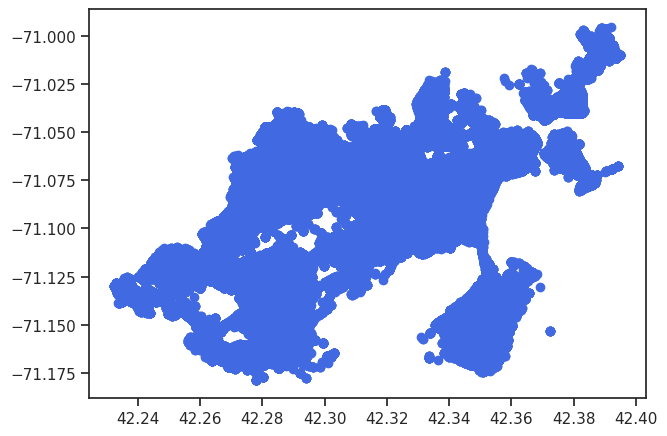

In [ ]:
plt.scatter(crime["Latitude"], crime["Longitude"], color = "royalblue")
plt.show()

In [ ]:
def Isolation_Forest(df, numerical_cols=['Year', 'Month', 'Hour', 'Latitude', 'Longitude', 'Offense_Code']):

    # Select relevant numerical columns
    X = df[numerical_cols].copy()

    # Handle potential NaN values if any (though we've cleaned the main DataFrame)
    # IsolationForest can handle NaNs by itself, but it's good practice to ensure numerical data.
    # For this demonstration, we'll assume X has no NaNs as per our cleaning steps.

    model = IsolationForest(n_estimators=100, max_samples='auto', contamination=0.02, random_state=42)
    # contamination is the proportion of outliers in the data set.
    # A value of 0.01 (1%) is a common starting point.

    model.fit(X)

    # FIX: Use X's index for prova, not crime.index
    prova = X.copy() # Create a DataFrame using X and its own index
    prova['scores'] = model.decision_function(X) # Anomaly score: lower is more anomalous
    prova['anomaly'] = model.predict(X) # -1 for outliers, 1 for inliers

    anomaly_df = prova.loc[prova['anomaly'] == -1]
    OUTLIER_INDEX = list(anomaly_df.index)

    print(f"Found {len(OUTLIER_INDEX)} outliers using Isolation Forest.")

    return anomaly_df, OUTLIER_INDEX

In [ ]:
def lof_outliers(df, numerical_cols = ['Year', 'Month', 'Hour', 'Latitude', 'Longitude', 'Offense_Code']):

    # Select the same numerical columns used for Isolation Forest
    X_lof = df[numerical_cols].copy()

    # Initialize LocalOutlierFactor model

    lof_model = LocalOutlierFactor(n_neighbors=20, contamination=0.02, novelty=False)

    # Fit the model and predict outliers
    # .fit_predict returns -1 for outliers and 1 for inliers
    # The negative_outlier_factor_ attribute contains the LOF scores
    lof_predictions = lof_model.fit_predict(X_lof)
    lof_scores = lof_model.negative_outlier_factor_

    # Create a DataFrame to store LOF results
    lof_results = X_lof.copy() # FIX: Use X_lof's index to match the data length
    lof_results['lof_scores'] = lof_scores
    lof_results['lof_anomaly'] = lof_predictions

    # Filter for outliers (where prediction is -1)
    lof_anomaly_df = lof_results.loc[lof_results['lof_anomaly'] == -1]
    LOF_OUTLIER_INDEX = list(lof_anomaly_df.index)

    print(f"Found {len(LOF_OUTLIER_INDEX)} outliers using Local Outlier Factor.")

    return lof_anomaly_df, LOF_OUTLIER_INDEX

In [ ]:
def plot_anomaly(df, anomaly_df):
    # Using Latitude and Longitude to visualize geographical outliers
    plt.figure(figsize=(10, 8))
    plt.scatter(df["Longitude"], df["Latitude"], color='royalblue', label='Normal points', alpha=0.6)
    plt.scatter(anomaly_df["Longitude"], anomaly_df["Latitude"], color='red', label='Outliers', s=50, alpha=0.8)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title("Outliers Detected by Isolation Forest (Geographical View)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

Found 6382 outliers using Isolation Forest.


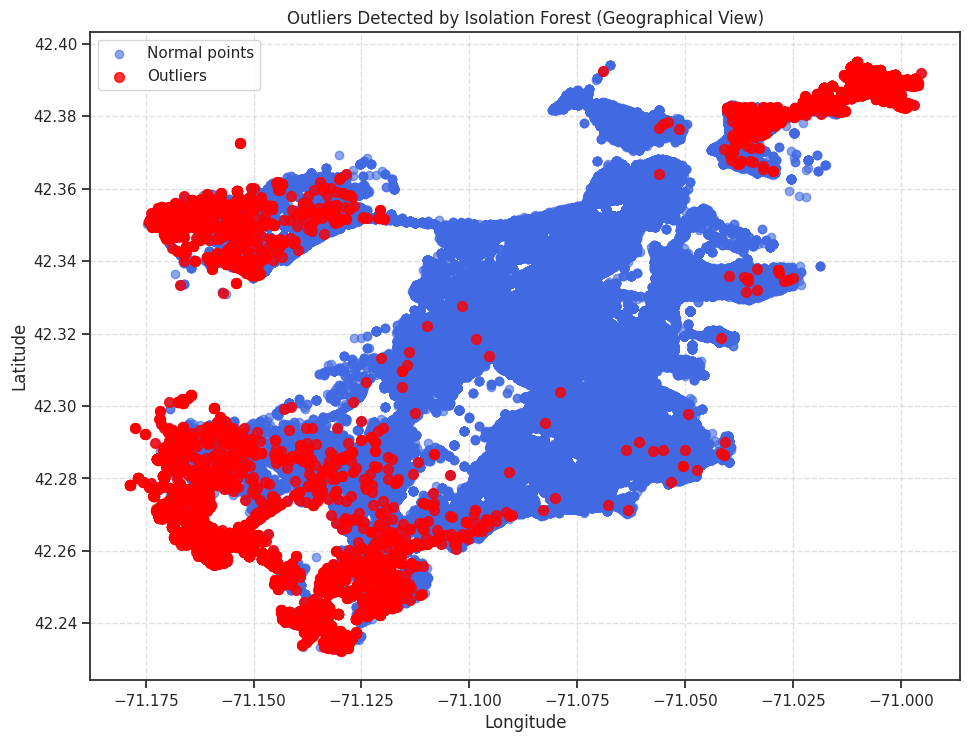

In [ ]:
anomaly_df, OUTLIER_INDEX = Isolation_Forest(crime)
plot_anomaly(crime, anomaly_df)

Found 6382 outliers using Local Outlier Factor.


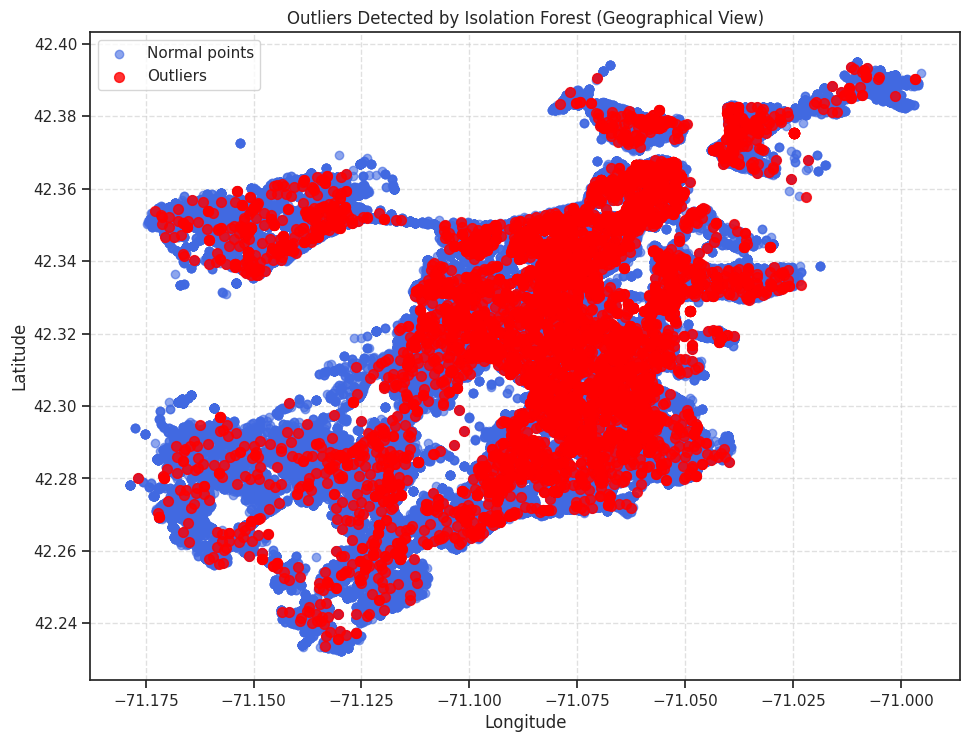

In [ ]:
lof_anomaly_df, LOF_OUTLIER_INDEX = lof_outliers(crime)
plot_anomaly(crime, lof_anomaly_df)

In [ ]:
# Identify the intersection of outliers found by both methods
common_outliers = list(set(OUTLIER_INDEX) & set(LOF_OUTLIER_INDEX))

print(f"Number of common outliers found by both Isolation Forest and LOF: {len(common_outliers)}")

# Remove common outliers from crime_knn DataFrame
before_removal_shape = crime.shape
crime_cleaned = crime.drop(index=common_outliers)

print(f"Shape of crime_knn before outlier removal: {before_removal_shape}")
print(f"Shape of crime_knn after common outlier removal: {crime_cleaned.shape}")

# Update crime_knn to the cleaned version
crime = crime_cleaned.copy()

print("Common outliers have been removed from crime_knn.")

Number of common outliers found by both Isolation Forest and LOF: 95
Shape of crime_knn before outlier removal: (319073, 18)
Shape of crime_knn after common outlier removal: (318978, 18)
Common outliers have been removed from crime_knn.


## 2.3 DATA DEDUPLICATION (EXACT + NON-EXACT)

1. Exact
2. Rule-based
3. Non-exact (record linkage)

In [ ]:
print(f"Shape BEFORE exact dedup: {crime.shape}")
crime = crime.drop_duplicates()
print(f"Shape AFTER exact dedup:  {crime.shape}")

Shape BEFORE exact dedup: (318949, 18)
Shape AFTER exact dedup:  (318949, 18)


Incident_ID should correspond to one real-world event, BUT this **event can content some crimes** (checked manually + domain knowledge assumption).


We therefore remove inconsistent duplicates and keep only records where ID, time, and place are consistent.

In [ ]:
bad_ids = (
    crime.groupby("Incident_ID")
    .filter(lambda g:
            (g["Date_Time"].nunique() > 1) or
            (g[["Latitude", "Longitude"]].drop_duplicates().shape[0] > 1)
           )["Incident_ID"]
    .unique()
)

# Drop rows where the same Incident_ID refers to different time or location
crime_dedup = (
    crime
    .assign(_bad=crime["Incident_ID"].isin(bad_ids))
    .sort_values("Date_Time")
    .drop_duplicates(subset=["Incident_ID"], keep="first")
    .drop(columns="_bad")
)

In [ ]:
crime = crime_dedup

In [ ]:
print(f"Shape AFTER rule-based dedup:  {crime.shape}")

Shape AFTER rule-based dedup:  (282440, 18)


NON-EXACT DEDUPLICATION record linkage

In [ ]:
crime_copy = crime.copy()

crime_copy["Latitude"] = crime_copy["Latitude"].astype(float)
crime_copy["Longitude"] = crime_copy["Longitude"].astype(float)
crime_copy["Hour"] = crime_copy["Hour"].astype(int)

crime_copy["Year"] = crime_copy["Year"].astype(int)
crime_copy["Month"] = crime_copy["Month"].astype(int)
crime_copy["District"] = crime_copy["District"].astype(str)
crime_copy["Offense_Code"] = crime_copy["Offense_Code"].astype(str)

# Hour binning (reduces comparisons a lot)
crime_copy["Hour_bin"] = (crime_copy["Hour"] // 3).astype(int)   # 0–2, 3–5, ..., 21–23

# Optional: round coordinates
crime_copy["Lat_round"] = crime_copy["Latitude"].round(3)
crime_copy["Lon_round"] = crime_copy["Longitude"].round(3)

indexer = recordlinkage.Index()
indexer.block(["Year", "Month", "District", "Hour_bin", "Lat_round", "Lon_round"])

compare = recordlinkage.Compare()

compare.numeric("Latitude", "Latitude", method="gauss", scale=0.001, label="lat")
compare.numeric("Longitude", "Longitude", method="gauss", scale=0.001, label="lon")
compare.numeric("Hour", "Hour", method="gauss", scale=1.5, label="hour")

compare.string("Street", "Street", method="jarowinkler", threshold=0.85, label="street")

compare.exact("Offense_Code", "Offense_Code", label="offense")

<Compare>

In [ ]:
pairs = indexer.index(crime_copy)
features = compare.compute(pairs, crime_copy)

In [ ]:
len(features)

113869

In [ ]:
y = (features.sum(axis=1) > 4).astype(int)

clf = LogisticRegression(
    max_iter=200,
    n_jobs=-1,
    class_weight="balanced"
)

clf.fit(features, y)
proba = clf.predict_proba(features)[:, 1]
matches = features[proba > 0.9]

We identify duplicate records by clustering highly similar record pairs using a graph-based approach.

In [ ]:
G = nx.Graph()
G.add_edges_from(matches.index.tolist())

clusters = list(nx.connected_components(G))

Each connected component represents a group of duplicate records.

In [ ]:
crime.loc[list(clusters[0])]

Button(description='Toggle Pandas/Lux', layout=Layout(top='5px', width='140px'), style=ButtonStyle())

Output()

In [ ]:
crime.loc[list(clusters[1111])]

Button(description='Toggle Pandas/Lux', layout=Layout(top='5px', width='140px'), style=ButtonStyle())

Output()

In [ ]:
def choose_rep(cluster, df):
    return df.loc[list(cluster)].sort_values(
        ["Date_Time"], ascending=True
    ).index[0]

For each group, we retain a single representative (earliest event in time),
while records not belonging to any cluster are kept unchanged.

In [ ]:
matched_idx = set()
for c in clusters:
    matched_idx |= set(c)

all_idx = set(crime_copy.index)
singletons = list(all_idx - matched_idx)

cluster_reps = [choose_rep(c, crime_copy) for c in clusters]

to_keep = cluster_reps + singletons

crime_dedup = (
    crime_copy
    .loc[to_keep]
    .sort_index()
    .reset_index(drop=True)
)

In [ ]:
len(crime), len(crime_dedup)

(282440, 271897)

In [ ]:
crime_dedup.drop(columns=["Hour_bin", "Lat_round", "Lon_round"])
crime = crime_dedup.copy()

BRIEF POST-CLEANING DQ ASSESSMENT

In [ ]:
dq_after = dq_assessment_table(crime)
print("\n=== POST-CLEANING DQ (brief) ===")
print("Global completeness:", float(dq_after["completeness_global"].iloc[0]))
print("\nWorst 8 columns by constancy (possible low information):")
print(dq_after.sort_values("constancy", ascending=False).head(8)[["column", "constancy"]])

print("\nWorst 8 columns by completeness proxy (use missing counts directly):")
print(crime.isna().sum().sort_values(ascending=False).head(8))

print("\nDuplicate rows remaining:", int(crime.duplicated().sum()))


=== POST-CLEANING DQ (brief) ===
Global completeness: 1.0

Worst 8 columns by constancy (possible low information):
      column     constancy
6      Shooting  0.997731 
17   Is_holiday  0.973508 
12     UCR_Part  0.525670 
8          Year  0.315814 
18     Hour_bin  0.175548 
4      District  0.156136 
10  Day_of_Week  0.151793 
2    Crime_Type  0.130568 

Worst 8 columns by completeness proxy (use missing counts directly):
Incident_ID          0
Offense_Code         0
Crime_Type           0
Crime_Description    0
District             0
Reporting_Area       0
Shooting             0
Date_Time            0
dtype: int64

Duplicate rows remaining: 0


# **3. DATA ANALYSIS**

## Classification

Basic logistic regression (comparison of dirty and clean).

In [ ]:
# -----------------------------
# Classification setup
# -----------------------------
FEATURES = [
    "Year",
    "Month",
    "Hour",
    "District",
    "Reporting_Area",
    "Shooting",
    "Is_holiday"
]

TARGET = "Crime_Type"


In [ ]:
def run_classification_pipeline(df, label="DATASET"):
    print(f"\n=== Running classification on {label} ===")

    # Keep only needed columns
    cols = FEATURES + [TARGET]
    data = df[cols].dropna(subset=[TARGET]).copy()

    X = data[FEATURES]
    y = data[TARGET]

      # Consolidate rare classes to enable stratified split
    min_count = 5
    vc = y.value_counts()
    rare = vc[vc < min_count].index
    if len(rare) > 0:
        y = y.where(~y.isin(rare), other="Other")

    # Train / test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.3,
        random_state=42,
        stratify=y
    )

    # Column types
    num_cols = X.select_dtypes(include="number").columns.tolist()
    cat_cols = X.select_dtypes(exclude="number").columns.tolist()

    # Preprocessing
    preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), num_cols),

            ("cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]), cat_cols),
        ]
    )


    # Model
    model = LogisticRegression(
        max_iter=1000,
        n_jobs=-1,
        class_weight="balanced"
    )

    pipeline = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", model),
        ]
    )

    # Training
    pipeline.fit(X_train, y_train)

    # Prediction
    y_pred = pipeline.predict(X_test)

    # Metrics
    f1_macro = f1_score(y_test, y_pred, average="macro")

    print(f"\nMacro F1-score ({label}): {f1_macro:.4f}")
    print("\nClassification report:")
    print(classification_report(y_test, y_pred))

    return f1_macro


In [ ]:
f1_dirty = run_classification_pipeline(crime_dirty, label="DIRTY DATA")
f1_clean = run_classification_pipeline(crime, label="CLEANED DATA")


=== Running classification on DIRTY DATA ===

Macro F1-score (DIRTY DATA): 0.0079

Classification report:
                                  precision    recall  f1-score   support

              Aggravated Assault       0.00      0.00      0.00      2342
                        Aircraft       0.00      1.00      0.01        11
                           Arson       0.00      0.00      0.00        28
Assembly or Gathering Violations       0.02      0.39      0.04       287
                      Auto Theft       0.00      0.00      0.00      1455
             Auto Theft Recovery       0.00      0.00      0.00       315
                      Ballistics       0.01      0.01      0.01       294
                       Bomb Hoax       0.00      0.09      0.00        23
             Commercial Burglary       0.02      0.02      0.02       401
                Confidence Games       0.00      0.00      0.00       944
                  Counterfeiting       0.00      0.00      0.00       436
    

In [ ]:
print("\n=== COMPARISON ===")
print(f"Macro F1 (dirty):  {f1_dirty:.4f}")
print(f"Macro F1 (clean):  {f1_clean:.4f}")
print(f"Δ F1 (clean - dirty): {f1_clean - f1_dirty:.4f}")


=== COMPARISON ===
Macro F1 (dirty):  0.0079
Macro F1 (clean):  0.0126
Δ F1 (clean - dirty): 0.0047


### Pipeline with grid search

In [ ]:
FEATURES = [
    "District",
    "Day_of_Week",
    "Is_holiday",
    "Hour",
    "Month",
    "Street",
    "Latitude",
    "Longitude"
]

TARGET = "Crime_Type"

In [ ]:
NUM_FEATURES = ["Hour", "Month", "Latitude", "Longitude"]
CAT_FEATURES = ["District", "Day_of_Week", "Street", "Is_holiday"]

In [ ]:
def build_preprocessor(cat_features, model_name):
    """
    Build preprocessing pipeline depending on the model type.
    """

    # ---------- Numerical pipeline ----------
    if model_name == "LogReg":
        num_pipe = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])
    else:
        # RF and XGB do NOT need scaling
        num_pipe = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median"))
        ])

    cat_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
    ])

    return ColumnTransformer(
        transformers=[
            ("num", num_pipe, NUM_FEATURES),
            ("cat", cat_pipe, cat_features)
        ],
        remainder="drop"
    )

In [ ]:
models = {
    "LogReg": LogisticRegression(max_iter=100, solver="saga", n_jobs=-1),
    "RF": RandomForestClassifier(random_state=42, max_features=0.3, max_samples=0.7),
}

In [ ]:
param_grids = {
    "LogReg": {
        "model__C": [0.01, 0.1, 1]
    },
    "RF": {
        "model__n_estimators": [50, 100],
        "model__max_depth": [3, 7]
    },
    "XGB": {
        "model__max_depth": [3, 6],
        "model__learning_rate": [0.05, 0.1]
    }
}

In [ ]:
def run_experiment(df, features, cat_features, models_dict, param_grids, label="dirty"):
    X = df[features]
    y = df[TARGET]

    # Consolidate rare classes
    min_count = 5
    vc = y.value_counts()
    rare = vc[vc < min_count].index
    if len(rare) > 0:
        y = y.where(~y.isin(rare), other="Other")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    label_encoder = LabelEncoder()
    y_train_encoded = label_encoder.fit_transform(y_train)

    results = []
    trained_models = {}
    grids = {}
    preprocessors = {}

    for name, model in models_dict.items():
        print(f"\nTraining {name}...")

        preprocessor = build_preprocessor(cat_features, name)

        pipe = Pipeline(
            steps=[
                ("prep", preprocessor),
                ("model", model)
            ]
        )

        grid = HalvingGridSearchCV(
            pipe,
            param_grid=param_grids[name],
            scoring="f1_weighted",
            cv=3,
            n_jobs=1,
            verbose=2,
            return_train_score=True
        )

        grid.fit(X_train, y_train_encoded)
        y_pred_encoded = grid.predict(X_test)

        y_pred = label_encoder.inverse_transform(y_pred_encoded)

        results.append({
            "dataset": label,
            "model": name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, average="weighted"),
            "recall": recall_score(y_test, y_pred, average="weighted"),
            "f1": f1_score(y_test, y_pred, average="weighted"),
            "best_params": grid.best_params_
        })

        trained_models[name] = grid.best_estimator_
        grids[name] = grid
        preprocessors[name] = preprocessor

        print(classification_report(y_test, y_pred))

    return pd.DataFrame(results), preprocessors, grids, trained_models

In [ ]:
results_dirty, preprocessors_dirty, grids_dirty, models_dirty = run_experiment(
    crime_dirty,
    FEATURES,
    CAT_FEATURES,
    models,
    param_grids,
    label="dirty"
)

results_clean, preprocessors_clean, grids_clean, models_clean = run_experiment(
    crime,
    FEATURES,
    CAT_FEATURES,
    models,
    param_grids,
    label="clean"
)


Training LogReg...
n_iterations: 2
n_required_iterations: 2
n_possible_iterations: 2
min_resources_: 85086
max_resources_: 255258
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 3
n_resources: 85086
Fitting 3 folds for each of 3 candidates, totalling 9 fits
[CV] END ......................................model__C=0.01; total time=  27.7s
[CV] END ......................................model__C=0.01; total time=  19.8s
[CV] END ......................................model__C=0.01; total time=  21.2s
[CV] END .......................................model__C=0.1; total time=  19.4s
[CV] END .......................................model__C=0.1; total time=  21.6s
[CV] END .......................................model__C=0.1; total time=  19.1s
[CV] END .........................................model__C=1; total time=  20.0s
[CV] END .........................................model__C=1; total time=  20.6s
[CV] END .........................................model__C=1; total 

In [ ]:
results_all = pd.concat(
    [results_dirty, results_clean],
    ignore_index=True
)

In [ ]:
metrics = ["accuracy", "precision", "recall", "f1"]

comparison_table = (
    results_all
    .pivot(index="model", columns="dataset", values=metrics)
    .round(4)
)

comparison_table

Button(description='Toggle Pandas/Lux', layout=Layout(top='5px', width='140px'), style=ButtonStyle())

Output()

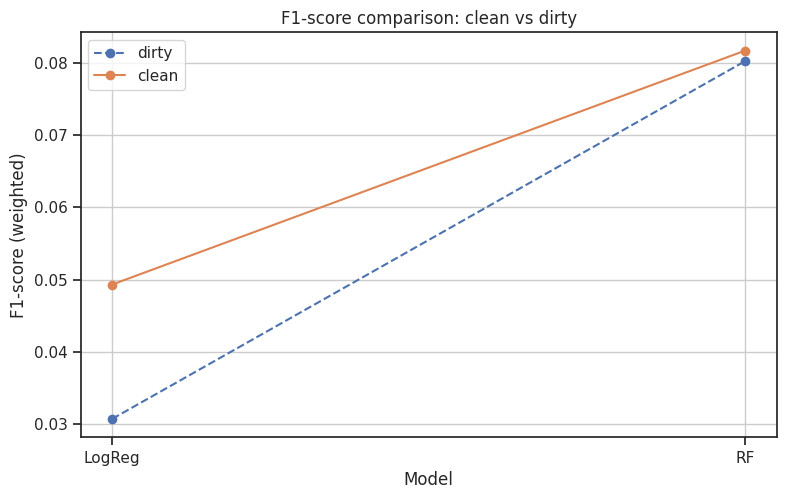

In [ ]:
plt.figure(figsize=(8, 5))

for dataset, style in zip(["dirty", "clean"], ["--", "-"]):
    subset = results_all[results_all["dataset"] == dataset]
    plt.plot(
        subset["model"],
        subset["f1"],
        marker="o",
        linestyle=style,
        label=dataset
    )

plt.title("F1-score comparison: clean vs dirty")
plt.ylabel("F1-score (weighted)")
plt.xlabel("Model")
plt.legend()
plt.grid(True)
plt.show()

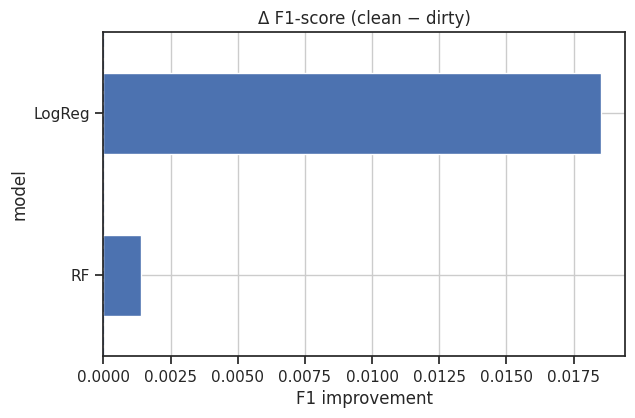

In [ ]:
delta = (
    comparison_table
    .xs("clean", level=1, axis=1)
    - comparison_table.xs("dirty", level=1, axis=1)
)

delta_f1 = delta["f1"].sort_values()

plt.figure(figsize=(6, 4))
delta_f1.plot(kind="barh")
plt.axvline(0, linestyle="--")
plt.title("Δ F1-score (clean − dirty)")
plt.xlabel("F1 improvement")
plt.grid(True)
plt.show()

In [ ]:
def extract_cv_metrics(grid, metric="mean_test_score", alpha=0.95):
    """
    Extract mean ± confidence interval for CV results.

    grid: fitted GridSearchCV
    metric: string, metric name in cv_results_ (default "mean_test_score")
    alpha: confidence level (default 95%)

    Returns: mean, lower, upper
    """
    mean = grid.cv_results_[metric].max()
    # std across folds
    std = grid.cv_results_["std_test_score"][grid.cv_results_[metric].argmax()]

    # 95% CI
    ci = 1.96 * std  # approximation, normal dist
    lower = mean - ci
    upper = mean + ci
    return mean, lower, upper

def collect_cv_metrics(grids_dict, label):
    rows = []
    for model_name, grid in grids_dict.items():
        mean, lower, upper = extract_cv_metrics(grid)
        rows.append({
            "dataset": label,
            "model": model_name,
            "f1_mean": mean,
            "f1_lower": lower,
            "f1_upper": upper
        })
    return pd.DataFrame(rows)

def collect_cv_metrics(grids_dict, label):
    rows = []
    for model_name, grid in grids_dict.items():
        mean, lower, upper = extract_cv_metrics(grid)
        rows.append({
            "dataset": label,
            "model": model_name,
            "f1_mean": mean,
            "f1_lower": lower,
            "f1_upper": upper
        })
    return pd.DataFrame(rows)



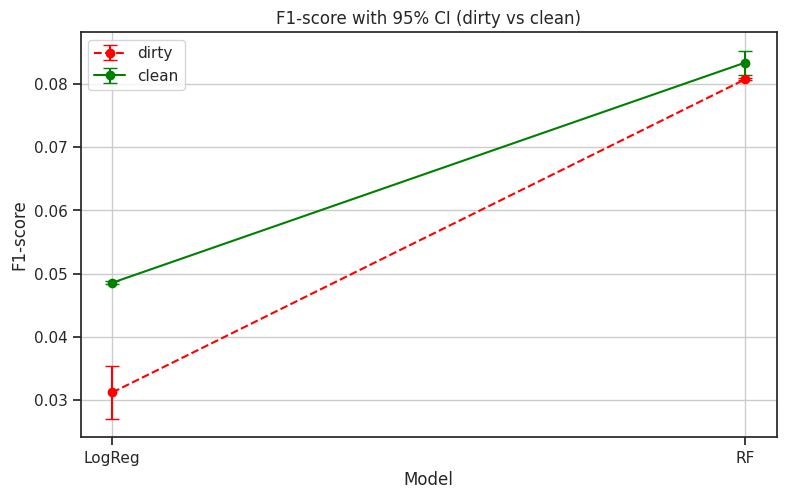

In [ ]:
cv_dirty = collect_cv_metrics(grids_dirty, "dirty")
cv_clean = collect_cv_metrics(grids_clean, "clean")

cv_all = pd.concat([cv_dirty, cv_clean], ignore_index=True)

plt.figure(figsize=(8,5))

for dataset, style, color in zip(["dirty", "clean"], ["--", "-"], ["red", "green"]):
    subset = cv_all[cv_all["dataset"]==dataset]
    plt.errorbar(
        subset["model"],
        subset["f1_mean"],
        yerr=[subset["f1_mean"] - subset["f1_lower"], subset["f1_upper"] - subset["f1_mean"]],
        fmt='o',
        linestyle=style,
        color=color,
        capsize=5,
        label=dataset
    )

plt.title("F1-score with 95% CI (dirty vs clean)")
plt.ylabel("F1-score")
plt.xlabel("Model")
plt.grid(True)
plt.legend()
plt.show()